# Equipment Dataset Exploration

This notebook explores equipment details extracted from permit documents, focusing on quantities, ages, capacities, fuel types, manufacturer coverage, and overall data completeness.


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

DATA_PATH = Path("/home/afhubbard/permit_data_extraction/data/processed/permit_data_extracted_combined.xlsx")

df_raw = pd.read_excel(DATA_PATH)
df_raw.head()


,Filename,Status,Facility Name,Facility Address,Facility City,Facility State Abbreviation,Facility Zip Code,Facility County,NAICS Code,Operating Hours,Industry Description,Permit Number,Issuance Date,Expiration Date,Regulatory Authority,"Primary Applicable Regulations (e.g., Title V, PSD, NESHAP Subpart)",Unit ID,Unit Description,Unit Quantity,Unit Make,Unit Model,Year of Manufacture,Unit Type,Pollutants,Emission Limits,Control Device(s),Capacity Value,Capacity Unit,Fuel Type,Rated Efficiency,Annual Run Hours,Generation Capacity,Spec Sheet Link,_source_file
0,10050_TV_Permit,Success,"General Dynamics-Mission Systems, Inc. – Plant 1",325 Brunswick Lane,Marion,VA,24354,Smyth,"332311, 336412, 336413, 336419, 336992",NaN,The company manufactures metal shelters and re...,SWRO10050VA,2023-10-10,2028-10-09,Virginia Department of Environmental Quality,"Title V, 9VAC5 Chapter 80 Article 1, 40 CFR 63...",1-4,"Aluminum wash, rinse, acid wash tanks",4,NaN,NaN,NaN,Metal Cleaning Tanks,PM/PM10,NaN,Venturi scrubbers for acid tanks,"6,000",lb product/hr,NaN,NaN,NaN,NaN,NaN,permit_data_extracted_v1.xlsx
1,10050_TV_Permit,Success,"General Dynamics-Mission Systems, Inc. – Plant 1",325 Brunswick Lane,Marion,VA,24354,Smyth,"332311, 336412, 336413, 336419, 336992",NaN,The company manufactures metal shelters and re...,SWRO10050VA,2023-10-10,2028-10-09,Virginia Department of Environmental Quality,"Title V, 9VAC5 Chapter 80 Article 1, 40 CFR 63...",114,"Kohler emergency generator, GM Engine 52729 (p...",1,Kohler,GM Engine 52729,2009,Emergency Engine,"Hydrocarbons + NOx, CO",Hydrocarbons + NOx: 13.4 g/kW-hr; CO: 519 g/kW...,NaN,42,kW,Propane,NaN,≤100 hours/year for maintenance/testing; ≤50 h...,42 kW,NaN,permit_data_extracted_v1.xlsx
2,10050_TV_Permit,Success,"General Dynamics-Mission Systems, Inc. – Plant 1",325 Brunswick Lane,Marion,VA,24354,Smyth,"332311, 336412, 336413, 336419, 336992",NaN,The company manufactures metal shelters and re...,SWRO10050VA,2023-10-10,2028-10-09,Virginia Department of Environmental Quality,"Title V, 9VAC5 Chapter 80 Article 1, 40 CFR 63...",18,Cleaver Brooks Model D-68 gas/oil boiler,1,Cleaver Brooks,D-68,1972,Boiler,"SO2, NOx, CO, PM","SO2: 32.3 lb/hr, 3.8 tons/year; NOx (as NO2): ...",Proper operation and maintenance; operator tra...,50.2,MMBtu/hr,"Natural gas, distillate oil (ASTM D396 No. 1 o...",NaN,NaN,NaN,NaN,permit_data_extracted_v1.xlsx
3,10050_TV_Permit,Success,"General Dynamics-Mission Systems, Inc. – Plant 1",325 Brunswick Lane,Marion,VA,24354,Smyth,"332311, 336412, 336413, 336419, 336992",NaN,The company manufactures metal shelters and re...,SWRO10050VA,2023-10-10,2028-10-09,Virginia Department of Environmental Quality,"Title V, 9VAC5 Chapter 80 Article 1, 40 CFR 63...",19,Cleaver Brooks Model CB-200-300 gas/oil boiler,1,Cleaver Brooks,CB-200-300,1985,Boiler,"SO2, NOx, CO, PM","SO2: 32.3 lb/hr, 3.8 tons/year (combined with ...",Proper operation and maintenance; operator tra...,12.5,MMBtu/hr,"Natural gas, distillate oil (ASTM D396 No. 1 o...",NaN,NaN,NaN,NaN,permit_data_extracted_v1.xlsx
4,10050_TV_Permit,Success,"General Dynamics-Mission Systems, Inc. – Plant 1",325 Brunswick Lane,Marion,VA,24354,Smyth,"332311, 336412, 336413, 336419, 336992",NaN,The company manufactures metal shelters and re...,SWRO10050VA,2023-10-10,2028-10-09,Virginia Department of Environmental Quality,"Title V, 9VAC5 Chapter 80 Article 1, 40 CFR 63...","20, 46, 57, 58, 61, 66, 67, FWG1-11, 80, 95, 107","Trimming panels, sanding and grinding of compo...",12,NaN,NaN,NaN,Grinding/Sanding/Routing,PM/PM10,"PM10: 26.6 lb/hr, 13.8 tons/year (combined)","Baghouses, fiberglass filters","Panel trim: 600; sanding: 4,000; grinding: 200",lb product/hr,NaN,NaN,NaN,NaN,NaN,permit_data_extracted_v1.xlsx


In [20]:
# Basic cleanup

cols_to_keep = [
    "Facility Name",
    "Permit Number",
    "Facility State Abbreviation",
    "NAICS Code",
    "Industry Description",
    "Unit ID",
    "Unit Description",
    "Unit Quantity",
    "Unit Make",
    "Unit Model",
    "Unit Type",
    "Year of Manufacture",
    "Fuel Type",
    "Capacity Value",
    "Capacity Unit",
    "Rated Efficiency",
    "Annual Run Hours"
]

equipment_core_fields = [
    "Unit ID",
    "Unit Description",
    "Unit Quantity",
    "Unit Make",
    "Unit Model",
    "Unit Type",
    "Year of Manufacture",
    "Fuel Type",
    "Capacity Value",
    "Capacity Unit",
    "Rated Efficiency",
    "Annual Run Hours",
]

derived_equipment_fields = [
    "Equipment Age",
    "Fuel Type Category",
    "Unit Type Category",
]

field_availability_columns = equipment_core_fields + derived_equipment_fields

# Helper categorizers

def categorize_fuel_type(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if not text or text in {"na", "n/a", "none", "unknown"}:
        return np.nan
    text = text.replace("-", " ")

    if any(phrase in text for phrase in ["natural gas", "nat gas", "pipeline gas", "lng", "cng"]):
        return "Natural Gas"
    if any(phrase in text for phrase in ["propane", "lpg", "butane"]):
        return "Propane / LPG"
    if any(phrase in text for phrase in ["diesel", "distillate", "fuel oil", "no. 2", "no 2", "#2", "# 2", "no. 4", "no 4", "#4", "# 4", "kerosene", "jet fuel"]):
        return "Fuel Oil / Diesel"
    if any(phrase in text for phrase in ["gasoline", "petrol"]):
        return "Gasoline"
    if any(phrase in text for phrase in ["coal", "anthracite", "bituminous", "lignite", "petcoke", "pet coke", "coke"]):
        return "Coal / Coke"
    if any(phrase in text for phrase in ["biomass", "wood", "sawdust", "hog fuel", "pellet", "bagasse", "fiber", "shavings"]):
        return "Biomass / Wood"
    if any(phrase in text for phrase in ["landfill gas", "lfg", "digester gas", "biogas"]):
        return "Biogas / Landfill Gas"
    if "hydrogen" in text:
        return "Hydrogen"
    if any(phrase in text for phrase in ["electric", "grid power", "kwh"]):
        return "Electricity"
    if any(phrase in text for phrase in ["steam", "compressed air"]):
        return "Utility / Other Non-Fuel"
    return "Other / Misc"


def categorize_unit_type(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if not text:
        return np.nan
    lower = text.lower()

    if any(keyword in lower for keyword in ["boiler", "heater", "furnace", "kiln", "oven", "burner", "hrsg", "steam generator"]):
        return "Combustion - Boilers & Heaters"
    if any(keyword in lower for keyword in ["turbine", "generator", "engine", "rice", "genset", "cogen", "compressor engine"]):
        return "Combustion - Engines & Turbines"
    if "flare" in lower:
        return "Combustion - Flares"
    if any(keyword in lower for keyword in ["oxidizer", "incinerator", "dryer", "roaster", "afterburner", "thermal oxidizer"]):
        return "Combustion - Thermal Processes"
    if any(keyword in lower for keyword in ["process", "line", "coating", "spray", "paint", "printing", "mix", "blend", "extrusion", "reactor"]):
        return "Process / Production Equipment"
    if any(keyword in lower for keyword in ["tank", "storage", "silo", "bin", "hopper", "pile", "conveyor", "loadout", "loading", "unloading"]):
        return "Storage & Material Handling"
    if any(keyword in lower for keyword in ["baghouse", "scrubber", "filter", "control device", "precipitator", "separator", "cyclone", "esp", "control system"]):
        return "Pollution Control Equipment"
    return "Other / Uncategorized"


# Filter out rows containing literal "ERROR" in any text field
object_cols = df_raw.select_dtypes(include="object").columns
error_mask = df_raw[object_cols].apply(lambda col: col.str.strip().eq("ERROR")).any(axis=1)
df_filtered = df_raw.loc[~error_mask].copy()

# Keep relevant columns
df = df_filtered[cols_to_keep].copy()

# Exclude data centers in Virginia
# Identify data centers by NAICS code 518210 (Data Processing, Hosting, and Related Services)
# or by facility name/description containing data center keywords
def is_data_center(row):
    """Check if a record is a data center"""
    # Check NAICS code
    naics_code = str(row.get('NAICS Code', '')).strip()
    if naics_code.startswith('518210') or naics_code == '518210':
        return True
    
    # Check facility name and industry description for data center keywords
    facility_name = str(row.get('Facility Name', '')).lower()
    industry_desc = str(row.get('Industry Description', '')).lower()
    
    data_center_keywords = ['data center', 'datacenter', 'data centre', 'server farm', 
                           'hosting', 'colocation', 'colo', 'cloud computing']
    
    combined_text = facility_name + ' ' + industry_desc
    if any(keyword in combined_text for keyword in data_center_keywords):
        return True
    
    return False

# Handle missing state values (matching presentation_visualizations logic)
df['Facility State Abbreviation'] = df['Facility State Abbreviation'].astype(str).str.strip().str.upper()
df['Facility State Abbreviation'] = df['Facility State Abbreviation'].replace(['NAN', 'NONE', ''], pd.NA)

# Filter out VA data centers
initial_count = len(df)
va_data_centers = df[
    (df['Facility State Abbreviation'] == 'VA') &
    df.apply(is_data_center, axis=1)
]

df = df[~(
    (df['Facility State Abbreviation'] == 'VA') &
    df.apply(is_data_center, axis=1)
)]

excluded_count = len(va_data_centers)
print(f"Loaded {initial_count:,} records after error filtering")
if excluded_count > 0:
    print(f"Excluded {excluded_count:,} data center records from Virginia")
print(f"Final dataset: {len(df):,} records")

# Normalize string columns
string_cols = [c for c in df.columns if df[c].dtype == "object"]
for col in string_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .replace({"nan": np.nan, "": np.nan})
    )

# Coerce numeric fields
numeric_cols = ["Unit Quantity", "Year of Manufacture", "Capacity Value", "Rated Efficiency", "Annual Run Hours"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Function to check if a NAICS code is an "industry" code
# Industry NAICS codes: 21 (Mining), 22 (Utilities), 23 (Construction), 31-33 (Manufacturing)
def is_industry_naics(naics_code):
    """Check if a NAICS code falls into industry sectors"""
    if pd.isna(naics_code):
        return False
    naics_str = str(naics_code).strip()
    if naics_str in ['nan', '', 'None']:
        return False
    if len(naics_str) < 2:
        return False
    sector_code = naics_str[:2]
    industry_sectors = ['21', '22', '23', '31', '32', '33']
    return sector_code in industry_sectors

# Create filtered dataframe for industry NAICS codes only
df_industry = df[df['NAICS Code'].apply(is_industry_naics)].copy()
print(f"\nFiltered to industry NAICS codes: {len(df_industry):,} records (from {len(df):,} total)")

# Derive age and categorical groupings (for both full and filtered datasets)
current_year = pd.Timestamp.today().year
df["Equipment Age"] = current_year - df["Year of Manufacture"]
df.loc[df["Year of Manufacture"].isna(), "Equipment Age"] = np.nan
df["Fuel Type Category"] = df["Fuel Type"].apply(categorize_fuel_type)
df["Unit Type Category"] = df["Unit Type"].apply(categorize_unit_type)

# Apply same derivations to filtered dataset
df_industry["Equipment Age"] = current_year - df_industry["Year of Manufacture"]
df_industry.loc[df_industry["Year of Manufacture"].isna(), "Equipment Age"] = np.nan
df_industry["Fuel Type Category"] = df_industry["Fuel Type"].apply(categorize_fuel_type)
df_industry["Unit Type Category"] = df_industry["Unit Type"].apply(categorize_unit_type)

df_industry.head()


Loaded 3,057 records after error filtering
Excluded 385 data center records from Virginia
Final dataset: 2,672 records

Filtered to industry NAICS codes: 1,398 records (from 2,672 total)


,Facility Name,Permit Number,Facility State Abbreviation,NAICS Code,Industry Description,Unit ID,Unit Description,Unit Quantity,Unit Make,Unit Model,Unit Type,Year of Manufacture,Fuel Type,Capacity Value,Capacity Unit,Rated Efficiency,Annual Run Hours,Equipment Age,Fuel Type Category,Unit Type Category
0,"General Dynamics-Mission Systems, Inc. – Plant 1",SWRO10050VA,VA,"332311, 336412, 336413, 336419, 336992",The company manufactures metal shelters and re...,1-4,"Aluminum wash, rinse, acid wash tanks",4.0,NaN,NaN,Metal Cleaning Tanks,NaN,NaN,NaN,lb product/hr,NaN,NaN,NaN,NaN,Storage & Material Handling
1,"General Dynamics-Mission Systems, Inc. – Plant 1",SWRO10050VA,VA,"332311, 336412, 336413, 336419, 336992",The company manufactures metal shelters and re...,114,"Kohler emergency generator, GM Engine 52729 (p...",1.0,Kohler,GM Engine 52729,Emergency Engine,2009.0,Propane,42.0,kW,NaN,NaN,16.0,Propane / LPG,Combustion - Engines & Turbines
2,"General Dynamics-Mission Systems, Inc. – Plant 1",SWRO10050VA,VA,"332311, 336412, 336413, 336419, 336992",The company manufactures metal shelters and re...,18,Cleaver Brooks Model D-68 gas/oil boiler,1.0,Cleaver Brooks,D-68,Boiler,1972.0,"Natural gas, distillate oil (ASTM D396 No. 1 o...",50.2,MMBtu/hr,NaN,NaN,53.0,Natural Gas,Combustion - Boilers & Heaters
3,"General Dynamics-Mission Systems, Inc. – Plant 1",SWRO10050VA,VA,"332311, 336412, 336413, 336419, 336992",The company manufactures metal shelters and re...,19,Cleaver Brooks Model CB-200-300 gas/oil boiler,1.0,Cleaver Brooks,CB-200-300,Boiler,1985.0,"Natural gas, distillate oil (ASTM D396 No. 1 o...",12.5,MMBtu/hr,NaN,NaN,40.0,Natural Gas,Combustion - Boilers & Heaters
4,"General Dynamics-Mission Systems, Inc. – Plant 1",SWRO10050VA,VA,"332311, 336412, 336413, 336419, 336992",The company manufactures metal shelters and re...,"20, 46, 57, 58, 61, 66, 67, FWG1-11, 80, 95, 107","Trimming panels, sanding and grinding of compo...",12.0,NaN,NaN,Grinding/Sanding/Routing,NaN,NaN,NaN,lb product/hr,NaN,NaN,NaN,NaN,Other / Uncategorized


## Data Overview


## Data Overview (All NAICS)


In [21]:
total_units_all = len(df)
unique_facilities_all = df["Facility Name"].nunique()

print(f"Total emission units (All NAICS): {total_units_all:,}")
print(f"Unique facilities: {unique_facilities_all:,}")

availability_cols_all = [col for col in field_availability_columns if col in df.columns]
availability_df_all = df[availability_cols_all]

availability_summary_all = (1 - availability_df_all.isna().mean()).sort_values(ascending=False)
availability_summary_all = (availability_summary_all * 100).round(1)
availability_summary_all


Total emission units (All NAICS): 2,672
Unique facilities: 199


Unit ID                99.6
Unit Description       99.5
Unit Type              99.5
Unit Type Category     99.5
Capacity Unit          78.4
Unit Quantity          70.6
Capacity Value         62.0
Fuel Type Category     56.0
Fuel Type              56.0
Unit Make              45.7
Unit Model             36.5
Year of Manufacture    32.4
Equipment Age          32.4
Annual Run Hours        6.4
Rated Efficiency        0.0
dtype: float64

## Data Availability Plot (All NAICS)


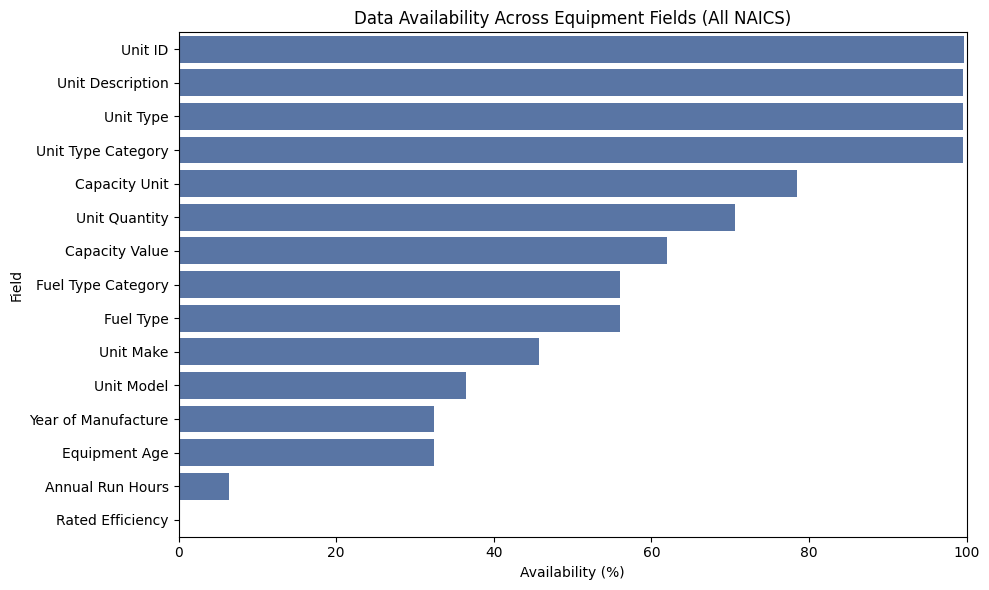

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=availability_summary_all.values, y=availability_summary_all.index, color="#4c72b0")
plt.xlabel("Availability (%)")
plt.ylabel("Field")
plt.title("Data Availability Across Equipment Fields (All NAICS)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


## Equipment Types and Quantities (All NAICS)


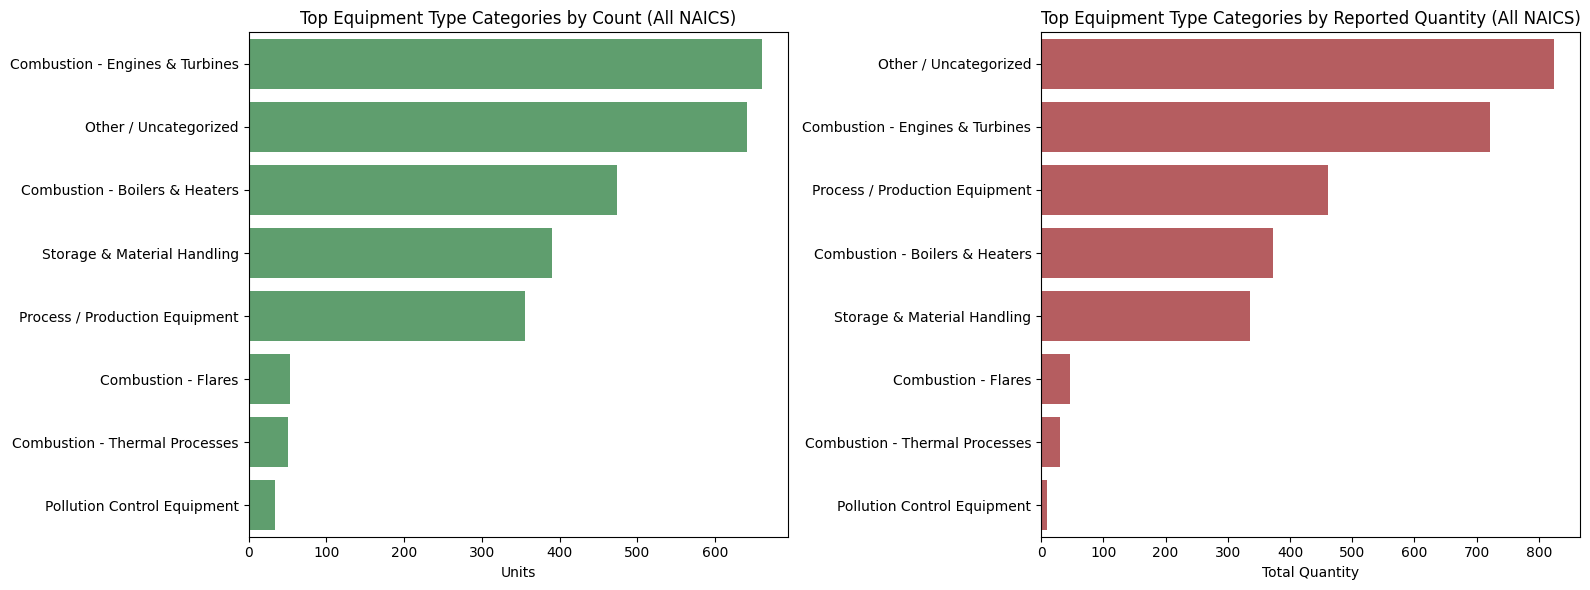

Unit Type Category
Combustion - Engines & Turbines    660
Other / Uncategorized              641
Combustion - Boilers & Heaters     474
Storage & Material Handling        390
Process / Production Equipment     355
Combustion - Flares                 53
Combustion - Thermal Processes      51
Pollution Control Equipment         34
Name: count, dtype: int64

In [23]:
type_counts_all = df["Unit Type Category"].dropna().value_counts().head(20)
type_quantity_all = (
    df.dropna(subset=["Unit Type Category", "Unit Quantity"])
      .groupby("Unit Type Category")["Unit Quantity"].sum()
      .sort_values(ascending=False)
      .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=type_counts_all.values, y=type_counts_all.index, ax=axes[0], color="#55a868")
axes[0].set_title("Top Equipment Type Categories by Count (All NAICS)")
axes[0].set_xlabel("Units")
axes[0].set_ylabel("")

sns.barplot(x=type_quantity_all.values, y=type_quantity_all.index, ax=axes[1], color="#c44e52")
axes[1].set_title("Top Equipment Type Categories by Reported Quantity (All NAICS)")
axes[1].set_xlabel("Total Quantity")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

type_counts_all.head(10)


## Equipment Age Distribution (All NAICS)


count    867.000000
mean      31.936563
std       18.887766
min        1.000000
25%       18.000000
50%       29.000000
75%       44.000000
90%       57.000000
max      122.000000
Name: Equipment Age, dtype: float64


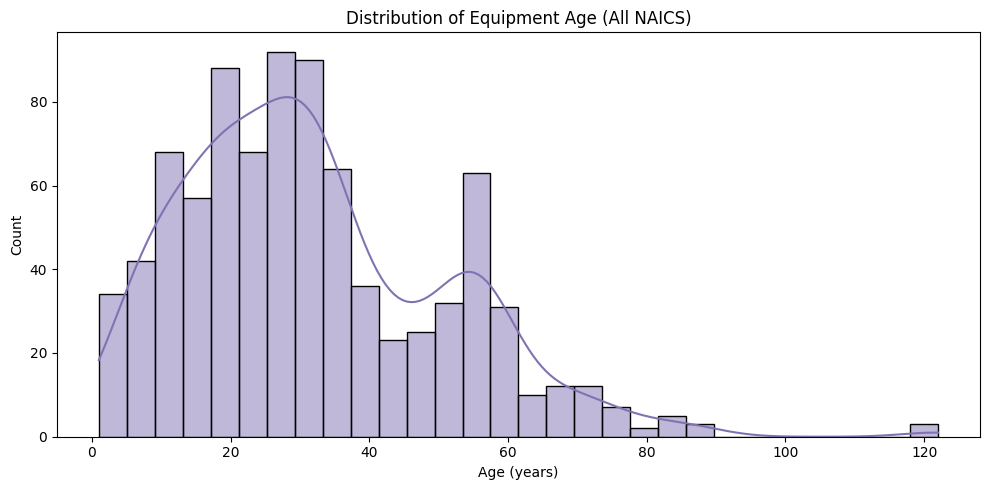

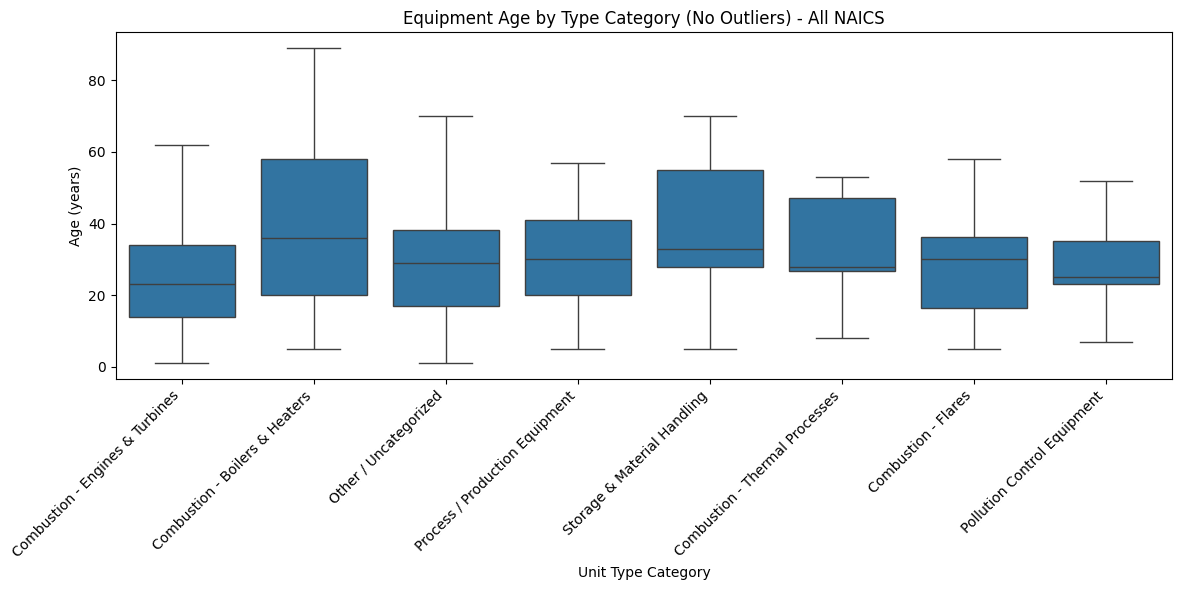

In [24]:
age_data_all = df["Equipment Age"].dropna()

age_summary_all = age_data_all.describe(percentiles=[0.25, 0.5, 0.75, 0.9])
print(age_summary_all)

plt.figure(figsize=(10, 5))
sns.histplot(age_data_all, bins=30, kde=True, color="#8172b2")
plt.title("Distribution of Equipment Age (All NAICS)")
plt.xlabel("Age (years)")
plt.tight_layout()
plt.show()

age_by_category_all = df.dropna(subset=["Unit Type Category", "Equipment Age"])

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=age_by_category_all,
    x="Unit Type Category",
    y="Equipment Age",
    showfliers=False,
)
plt.xticks(rotation=45, ha="right")
plt.title("Equipment Age by Type Category (No Outliers) - All NAICS")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()


## Equipment Capacity and Size (All NAICS)


In [25]:
capacity_df_all = df.dropna(subset=["Capacity Value", "Capacity Unit"])

capacity_by_unit_all = (
    capacity_df_all.groupby("Capacity Unit")
    .agg(count=("Capacity Value", "size"),
         median_capacity=("Capacity Value", "median"),
         p90_capacity=("Capacity Value", lambda x: np.nanpercentile(x, 90)))
    .sort_values("count", ascending=False)
)

capacity_by_unit_all.head(10)


,count,median_capacity,p90_capacity
Capacity Unit,,,
MMBtu/hr,507,14.6,185.64
gallons,137,500.0,2246137.60
kW,118,400.0,2000.00
HP,60,252.5,651.00
BHP,51,195.0,881.00
tons/hr,50,60.0,269.00
MMBTU/hr,49,7.5,46.20
hp,45,234.0,1994.00
lbs/hr,39,300.0,2200.00


## Capacity by Equipment Type (All NAICS)


In [26]:
# Filter to equipment with both capacity and fuel type (fuel-using equipment) - All NAICS
capacity_fuel_df_all = df.dropna(subset=["Capacity Value", "Fuel Type Category", "Unit Type Category"])

# Get top equipment types by count for better visualization
top_equip_for_capacity_all = capacity_fuel_df_all["Unit Type Category"].value_counts().head(8).index
capacity_fuel_filtered_all = capacity_fuel_df_all[capacity_fuel_df_all["Unit Type Category"].isin(top_equip_for_capacity_all)]

print(f"Equipment with capacity and fuel type data (All NAICS): {len(capacity_fuel_filtered_all):,}")
print(f"\nEquipment types included:")
for eq_type in top_equip_for_capacity_all:
    count = len(capacity_fuel_filtered_all[capacity_fuel_filtered_all["Unit Type Category"] == eq_type])
    print(f"  {eq_type}: {count} units")


Equipment with capacity and fuel type data (All NAICS): 1,145

Equipment types included:
  Combustion - Engines & Turbines: 542 units
  Combustion - Boilers & Heaters: 380 units
  Storage & Material Handling: 71 units
  Other / Uncategorized: 70 units
  Combustion - Flares: 29 units
  Process / Production Equipment: 27 units
  Combustion - Thermal Processes: 26 units


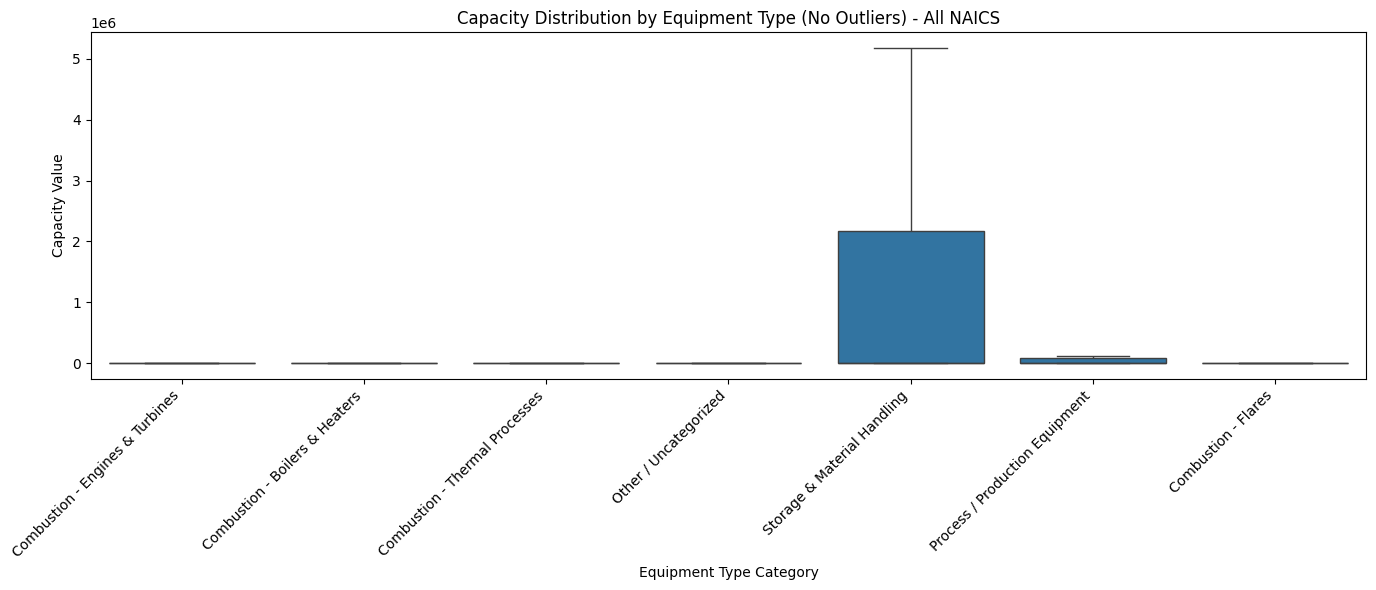


Capacity Summary Statistics by Equipment Type (All NAICS):
                                 count   median         mean          std  \
Unit Type Category                                                          
Combustion - Engines & Turbines    542   126.95     83047.27   1205985.50   
Combustion - Boilers & Heaters     380    26.50   4105389.14  33878144.96   
Storage & Material Handling         71  4000.00   8152483.77  60549164.91   
Other / Uncategorized               70    15.48   8144532.70  27530570.93   
Combustion - Flares                 29    77.80       966.57      1415.76   
Process / Production Equipment      27  1000.00  17809124.98  92369789.70   
Combustion - Thermal Processes      26    18.00        35.56        56.47   

                                  min          max  
Unit Type Category                                  
Combustion - Engines & Turbines  0.05   20900000.0  
Combustion - Boilers & Heaters   0.18  375000000.0  
Storage & Material Handling      1

In [27]:
# Box plot of capacity by equipment type (All NAICS)
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=capacity_fuel_filtered_all,
    x="Unit Type Category",
    y="Capacity Value",
    showfliers=False,
)
plt.xticks(rotation=45, ha="right")
plt.title("Capacity Distribution by Equipment Type (No Outliers) - All NAICS")
plt.ylabel("Capacity Value")
plt.xlabel("Equipment Type Category")
plt.tight_layout()
plt.show()

# Summary statistics
capacity_summary_all = (
    capacity_fuel_filtered_all.groupby("Unit Type Category")["Capacity Value"]
    .agg(["count", "median", "mean", "std", "min", "max"])
    .round(2)
    .sort_values("count", ascending=False)
)
print("\nCapacity Summary Statistics by Equipment Type (All NAICS):")
print(capacity_summary_all)


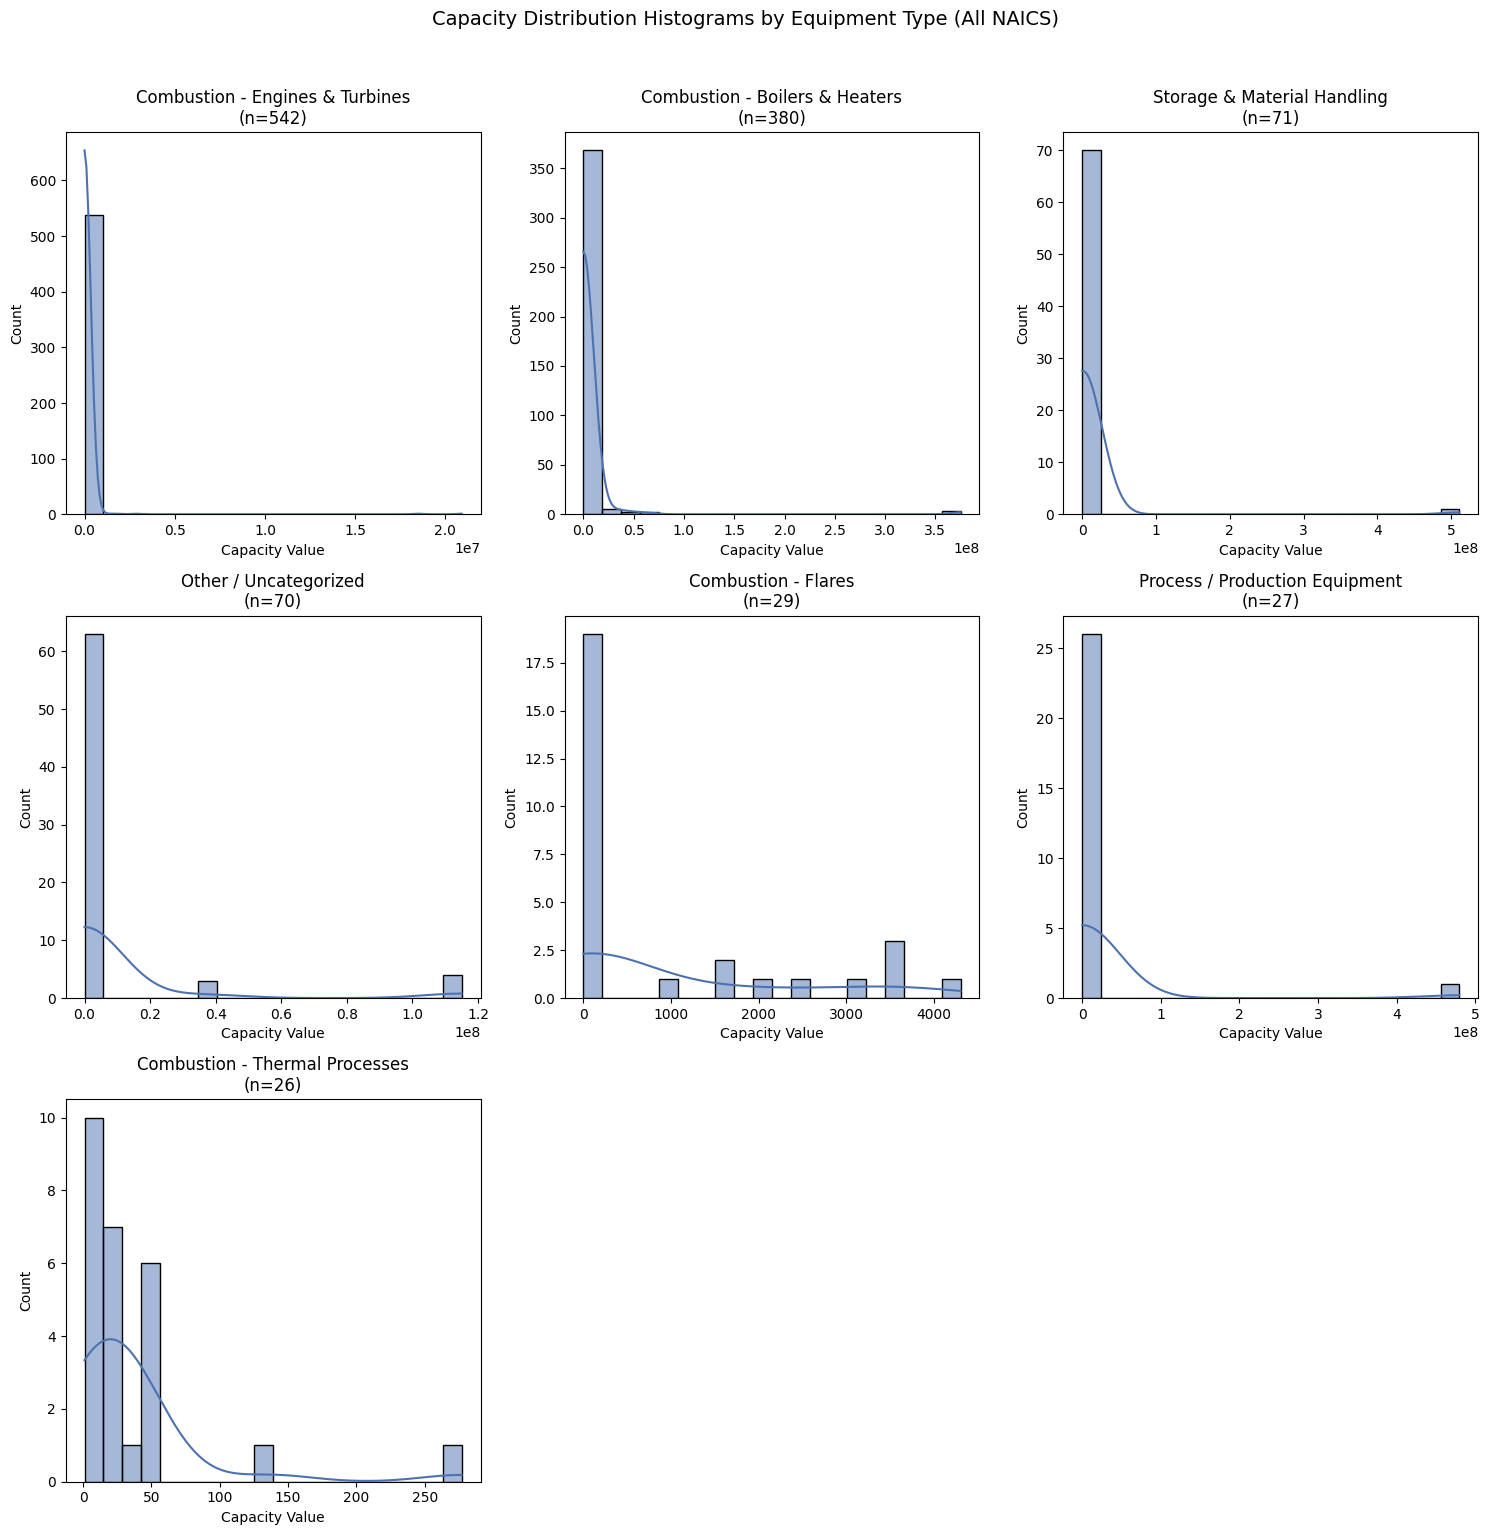

In [28]:
# Histograms by equipment type - faceted view (All NAICS)
n_types_all = len(top_equip_for_capacity_all)
n_cols = 3
n_rows = (n_types_all + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_types_all > 1 else [axes]

for idx, eq_type in enumerate(top_equip_for_capacity_all):
    subset = capacity_fuel_filtered_all[capacity_fuel_filtered_all["Unit Type Category"] == eq_type]
    if len(subset) > 0:
        sns.histplot(
            data=subset,
            x="Capacity Value",
            bins=20,
            kde=True,
            ax=axes[idx],
            color="#4c72b0",
        )
        axes[idx].set_title(f"{eq_type}\n(n={len(subset)})")
        axes[idx].set_xlabel("Capacity Value")
        axes[idx].set_ylabel("Count")

# Hide unused subplots
for idx in range(n_types_all, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Capacity Distribution Histograms by Equipment Type (All NAICS)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [29]:
# Focus on most common capacity unit for better comparison (All NAICS)
capacity_unit_counts_all = capacity_fuel_df_all["Capacity Unit"].value_counts()
print("Top capacity units (All NAICS):")
print(capacity_unit_counts_all.head(10))

# Filter to most common unit (likely MMBtu/hr for fuel-using equipment)
most_common_unit_all = capacity_unit_counts_all.index[0]
capacity_single_unit_all = capacity_fuel_df_all[capacity_fuel_df_all["Capacity Unit"] == most_common_unit_all]

top_equip_single_unit_all = capacity_single_unit_all["Unit Type Category"].value_counts().head(8).index
capacity_single_unit_filtered_all = capacity_single_unit_all[
    capacity_single_unit_all["Unit Type Category"].isin(top_equip_single_unit_all)
]

print(f"\nEquipment with {most_common_unit_all} (All NAICS): {len(capacity_single_unit_filtered_all):,} units")


Top capacity units (All NAICS):
Capacity Unit
MMBtu/hr    497
kW          117
HP           57
gallons      57
BHP          51
MMBTU/hr     48
hp           45
BTU/hr       23
kWe          20
MW           13
Name: count, dtype: int64

Equipment with MMBtu/hr (All NAICS): 497 units


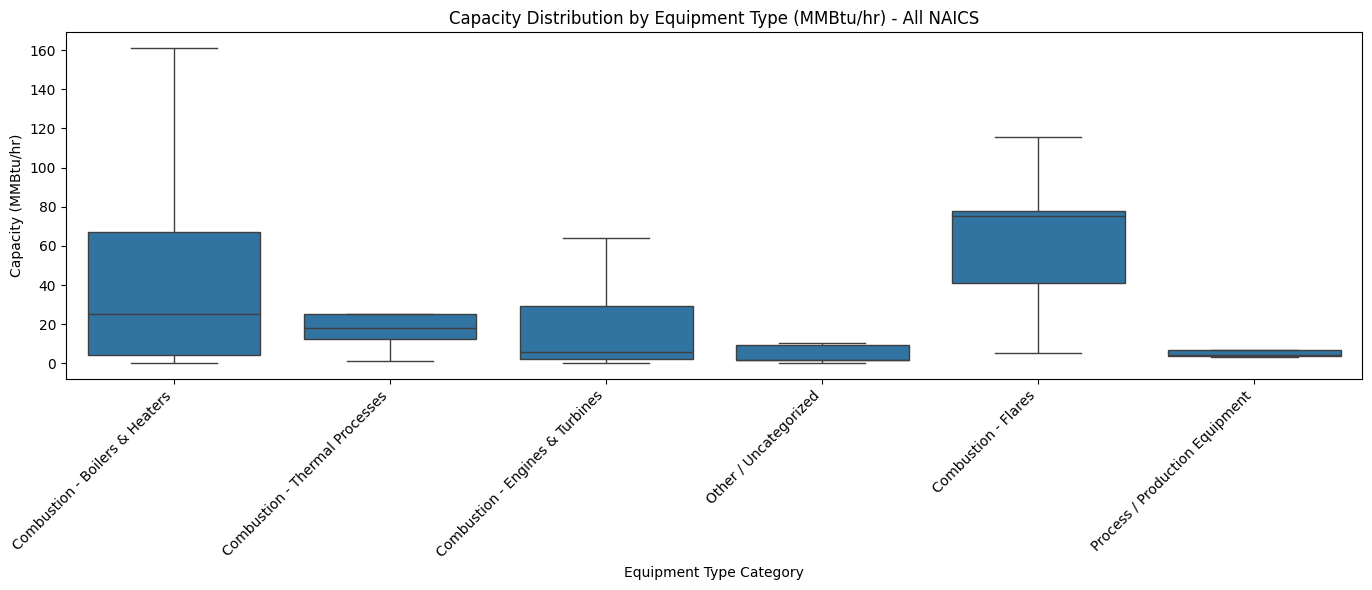

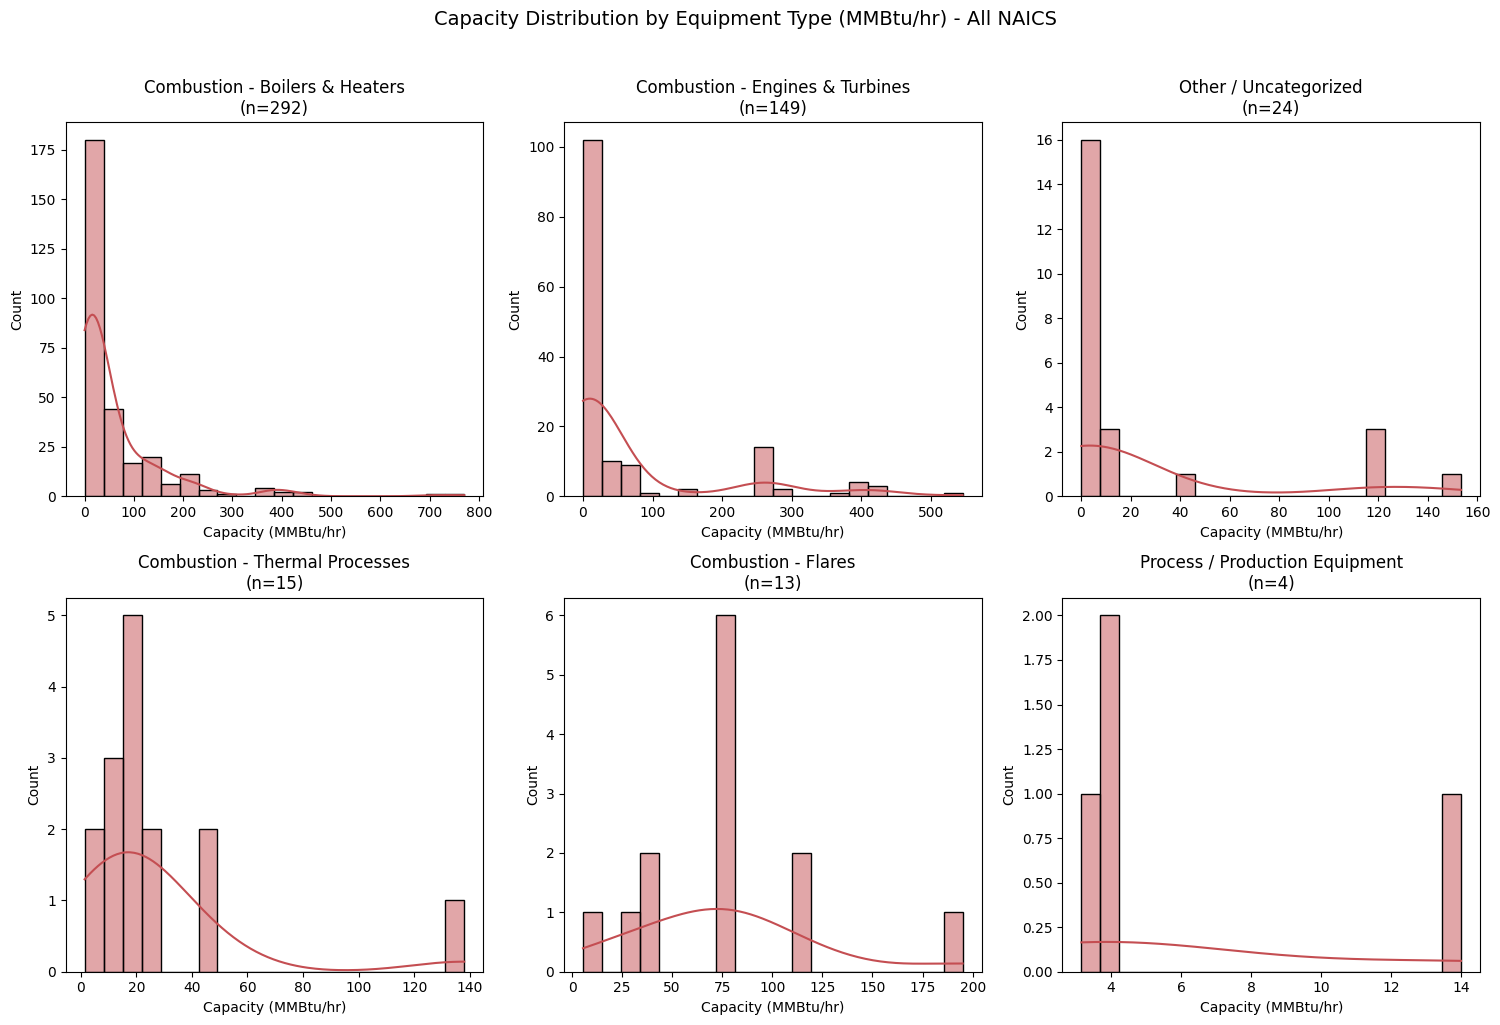

In [30]:
# Box plot for most common capacity unit (All NAICS)
if len(capacity_single_unit_filtered_all) > 0:
    plt.figure(figsize=(14, 6))
    sns.boxplot(
        data=capacity_single_unit_filtered_all,
        x="Unit Type Category",
        y="Capacity Value",
        showfliers=False,
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Capacity Distribution by Equipment Type ({most_common_unit_all}) - All NAICS")
    plt.ylabel(f"Capacity ({most_common_unit_all})")
    plt.xlabel("Equipment Type Category")
    plt.tight_layout()
    plt.show()
    
    # Histograms for most common unit (All NAICS)
    n_types_single_all = len(top_equip_single_unit_all)
    n_cols = 3
    n_rows = (n_types_single_all + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_types_single_all > 1 else [axes]
    
    for idx, eq_type in enumerate(top_equip_single_unit_all):
        subset = capacity_single_unit_filtered_all[
            capacity_single_unit_filtered_all["Unit Type Category"] == eq_type
        ]
        if len(subset) > 0:
            sns.histplot(
                data=subset,
                x="Capacity Value",
                bins=20,
                kde=True,
                ax=axes[idx],
                color="#c44e52",
            )
            axes[idx].set_title(f"{eq_type}\n(n={len(subset)})")
            axes[idx].set_xlabel(f"Capacity ({most_common_unit_all})")
            axes[idx].set_ylabel("Count")
    
    # Hide unused subplots
    for idx in range(n_types_single_all, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(
        f"Capacity Distribution by Equipment Type ({most_common_unit_all}) - All NAICS",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


## Fuel Type Mix (All NAICS)


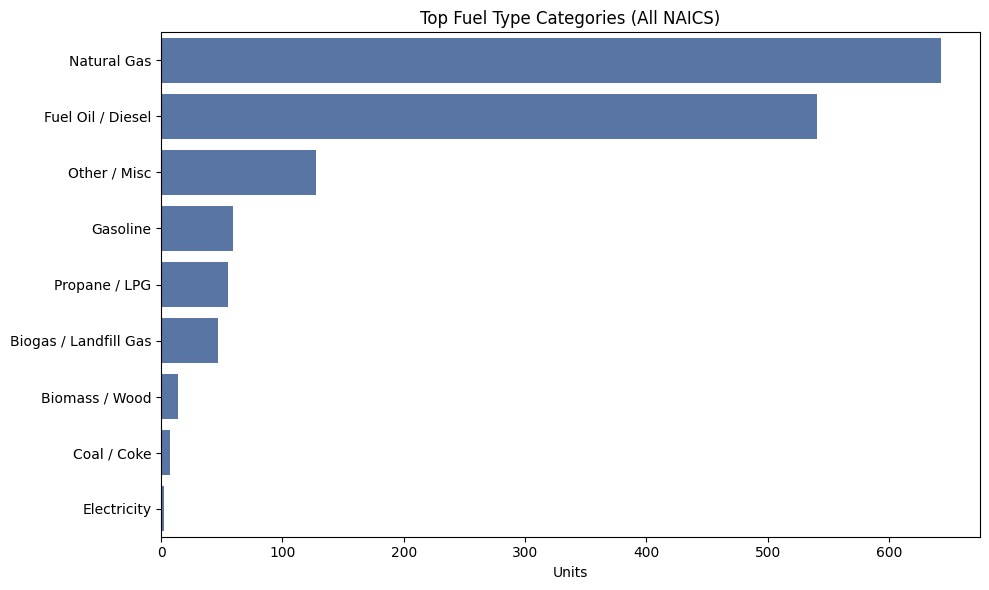

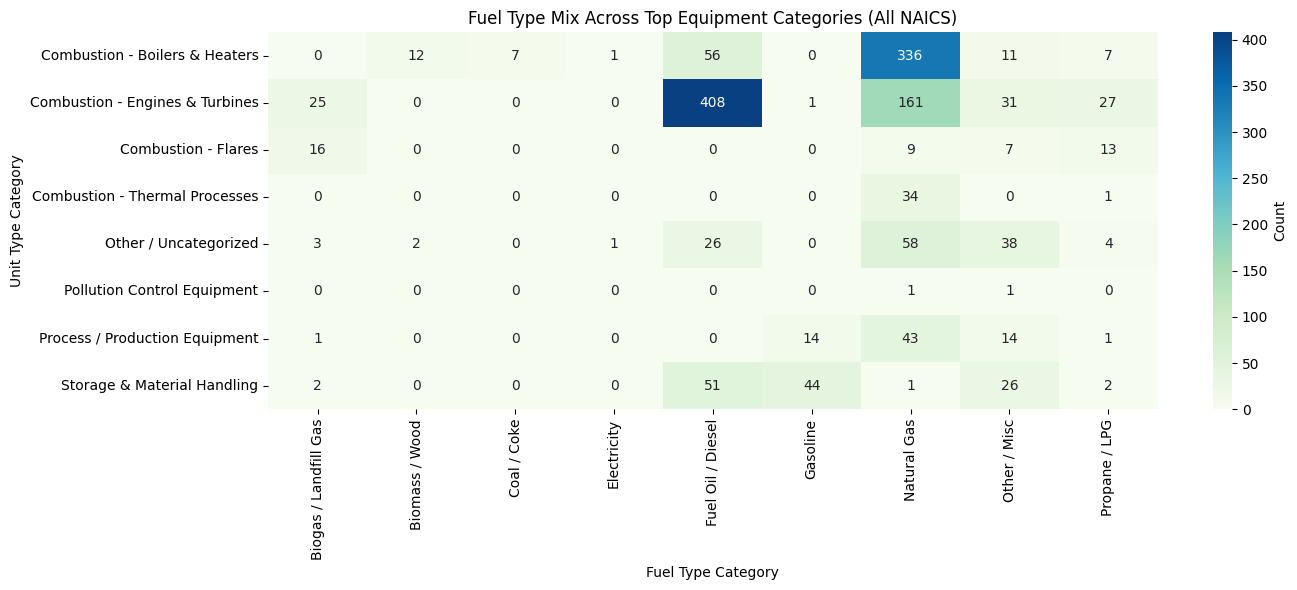

In [31]:
fuel_counts_all = df["Fuel Type Category"].dropna().value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=fuel_counts_all.values, y=fuel_counts_all.index, color="#4c72b0")
plt.title("Top Fuel Type Categories (All NAICS)")
plt.xlabel("Units")
plt.ylabel("")
plt.tight_layout()
plt.show()

fuel_type_by_unit_all = (
    df.dropna(subset=["Fuel Type Category", "Unit Type Category"])
      .groupby(["Unit Type Category", "Fuel Type Category"])
      .size()
      .reset_index(name="count")
)

top_unit_types_all = type_counts_all.index[:10]
top_fuel_types_all = fuel_counts_all.index[:10]

fuel_pivot_all = (
    fuel_type_by_unit_all[
        fuel_type_by_unit_all["Unit Type Category"].isin(top_unit_types_all)
        & fuel_type_by_unit_all["Fuel Type Category"].isin(top_fuel_types_all)
    ]
        .pivot_table(
            index="Unit Type Category",
            columns="Fuel Type Category",
            values="count",
            fill_value=0,
        )
)

plt.figure(figsize=(14, 6))
sns.heatmap(fuel_pivot_all, annot=True, fmt="g", cmap="GnBu", cbar_kws={"label": "Count"})
plt.title("Fuel Type Mix Across Top Equipment Categories (All NAICS)")
plt.xlabel("Fuel Type Category")
plt.ylabel("Unit Type Category")
plt.tight_layout()
plt.show()


## Manufacturer Representation (All NAICS)


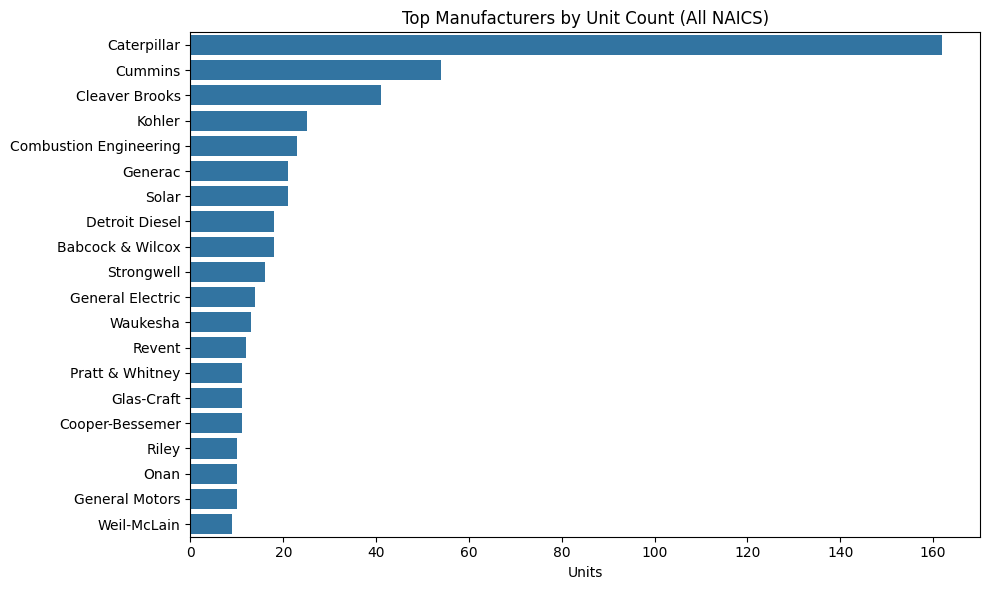

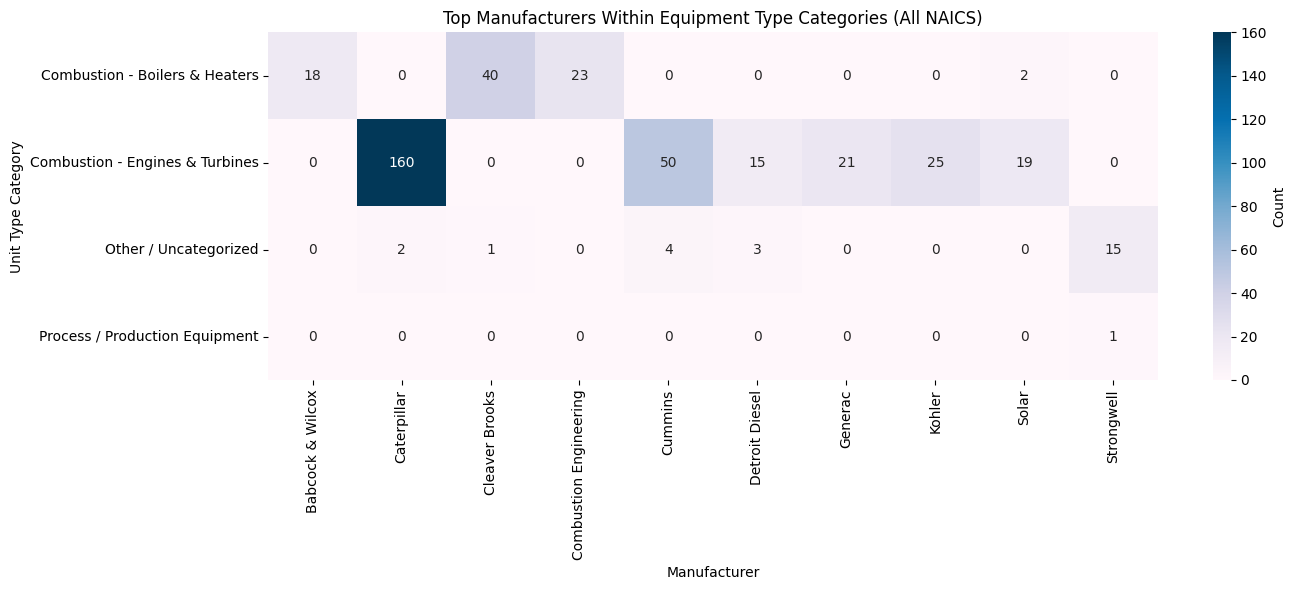

In [32]:
manufacturer_counts_all = df["Unit Make"].dropna().value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=manufacturer_counts_all.values, y=manufacturer_counts_all.index, color="#1f77b4")
plt.title("Top Manufacturers by Unit Count (All NAICS)")
plt.xlabel("Units")
plt.ylabel("")
plt.tight_layout()
plt.show()

manufacturers_by_type_all = (
    df.dropna(subset=["Unit Make", "Unit Type Category"])
      .groupby(["Unit Type Category", "Unit Make"])
      .size()
      .reset_index(name="count")
)

top_manufacturers_all = manufacturer_counts_all.index[:10]
top_types_all = type_counts_all.index[:10]

manufacturer_matrix_all = (
    manufacturers_by_type_all[
        manufacturers_by_type_all["Unit Make"].isin(top_manufacturers_all)
        & manufacturers_by_type_all["Unit Type Category"].isin(top_types_all)
    ]
    .pivot_table(index="Unit Type Category", columns="Unit Make", values="count", fill_value=0)
)

plt.figure(figsize=(14, 6))
sns.heatmap(manufacturer_matrix_all, cmap="PuBu", annot=True, fmt="g", cbar_kws={"label": "Count"})
plt.title("Top Manufacturers Within Equipment Type Categories (All NAICS)")
plt.xlabel("Manufacturer")
plt.ylabel("Unit Type Category")
plt.tight_layout()
plt.show()


## NAICS Code and Equipment Type Analysis (All NAICS)


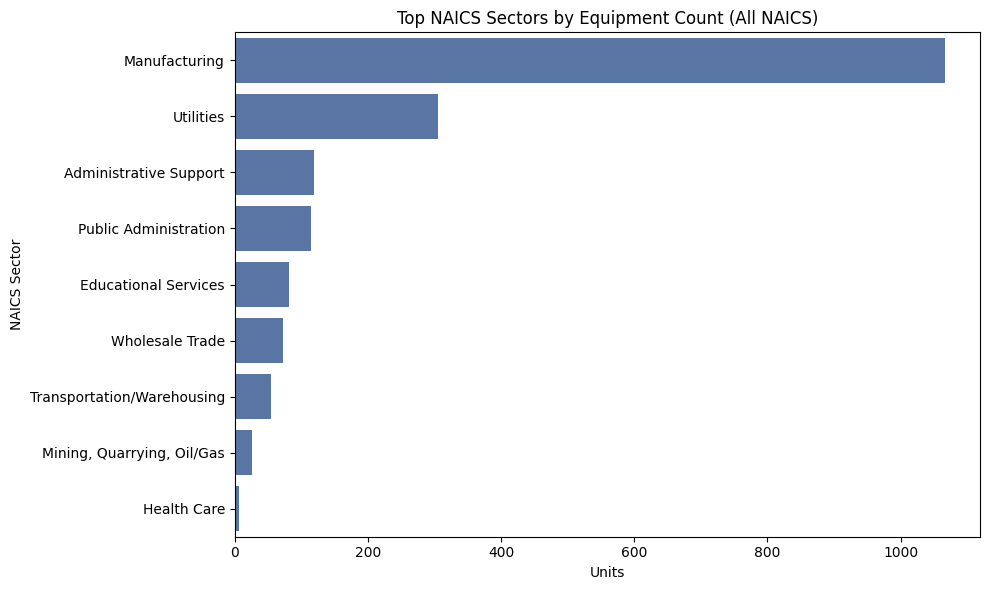

NAICS Sector Name
Manufacturing                 1066
Utilities                      306
Administrative Support         119
Public Administration          115
Educational Services            82
Wholesale Trade                 72
Transportation/Warehousing      54
Mining, Quarrying, Oil/Gas      26
Health Care                      7
Name: count, dtype: int64

In [33]:
# Clean and categorize NAICS codes (for all data)
df["NAICS Code"] = df["NAICS Code"].astype(str).str.strip()
df.loc[df["NAICS Code"].isin(["nan", "", "None"]), "NAICS Code"] = np.nan

# Extract 2-digit NAICS sector code
df["NAICS Sector"] = df["NAICS Code"].str[:2]
df.loc[df["NAICS Sector"].str.len() < 2, "NAICS Sector"] = np.nan

# Map 2-digit codes to sector names
naics_sector_map = {
    "11": "Agriculture, Forestry, Fishing",
    "21": "Mining, Quarrying, Oil/Gas",
    "22": "Utilities",
    "23": "Construction",
    "31": "Manufacturing",
    "32": "Manufacturing",
    "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade",
    "45": "Retail Trade",
    "48": "Transportation/Warehousing",
    "49": "Transportation/Warehousing",
    "51": "Information",
    "52": "Finance/Insurance",
    "53": "Real Estate",
    "54": "Professional Services",
    "55": "Management",
    "56": "Administrative Support",
    "61": "Educational Services",
    "62": "Health Care",
    "71": "Arts/Entertainment",
    "72": "Accommodation/Food",
    "81": "Other Services",
    "92": "Public Administration",
}

df["NAICS Sector Name"] = df["NAICS Sector"].map(naics_sector_map)

naics_counts_all_analysis = df["NAICS Sector Name"].dropna().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=naics_counts_all_analysis.values, y=naics_counts_all_analysis.index, color="#4c72b0")
plt.title("Top NAICS Sectors by Equipment Count (All NAICS)")
plt.xlabel("Units")
plt.ylabel("NAICS Sector")
plt.tight_layout()
plt.show()

naics_counts_all_analysis.head(10)


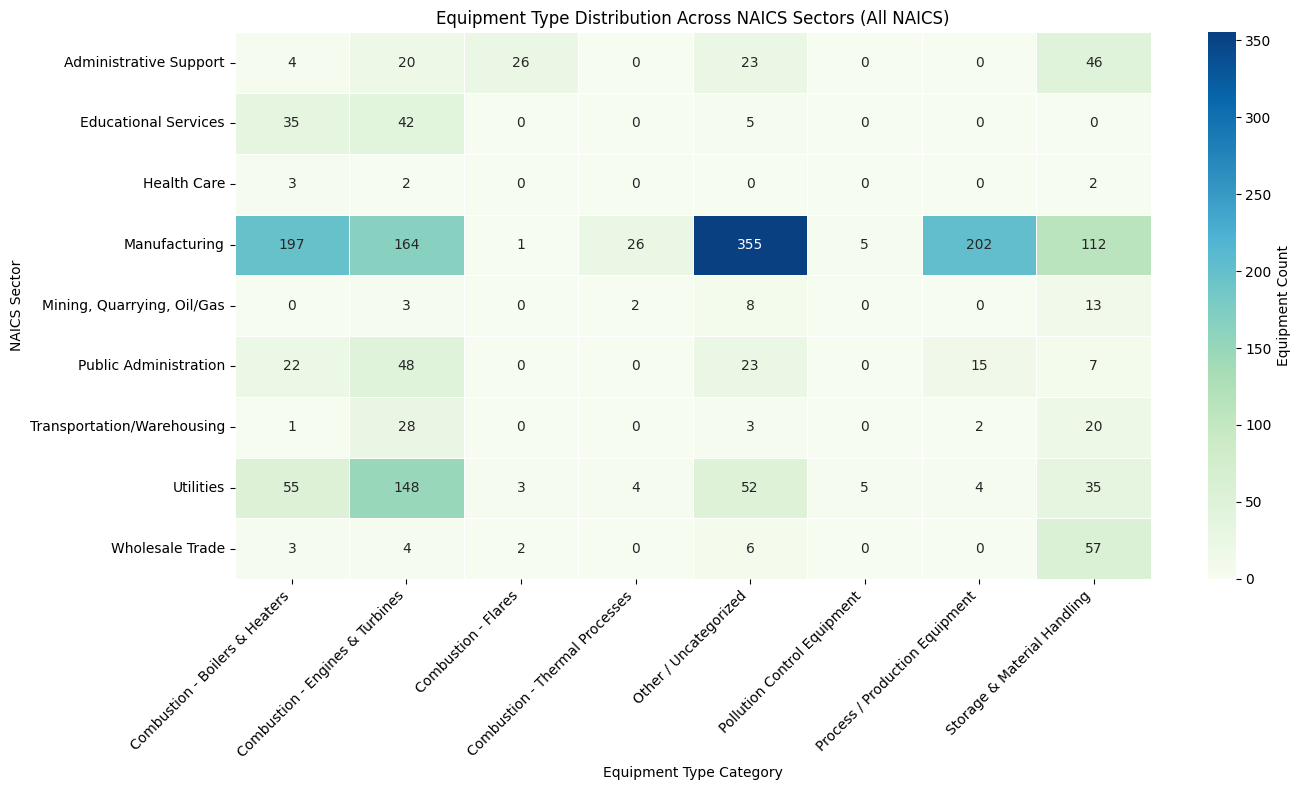

In [34]:
# Cross-tabulation of NAICS sectors and equipment types (All NAICS)
naics_equipment_all = (
    df.dropna(subset=["NAICS Sector Name", "Unit Type Category"])
      .groupby(["NAICS Sector Name", "Unit Type Category"])
      .size()
      .reset_index(name="count")
)

top_naics_all = naics_counts_all_analysis.index[:10]
top_equip_types_all = type_counts_all.index[:10]

naics_equip_matrix_all = (
    naics_equipment_all[
        naics_equipment_all["NAICS Sector Name"].isin(top_naics_all)
        & naics_equipment_all["Unit Type Category"].isin(top_equip_types_all)
    ]
    .pivot_table(
        index="NAICS Sector Name",
        columns="Unit Type Category",
        values="count",
        fill_value=0,
    )
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    naics_equip_matrix_all,
    annot=True,
    fmt="g",
    cmap="GnBu",
    cbar_kws={"label": "Equipment Count"},
    linewidths=0.5,
)
plt.title("Equipment Type Distribution Across NAICS Sectors (All NAICS)")
plt.xlabel("Equipment Type Category")
plt.ylabel("NAICS Sector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


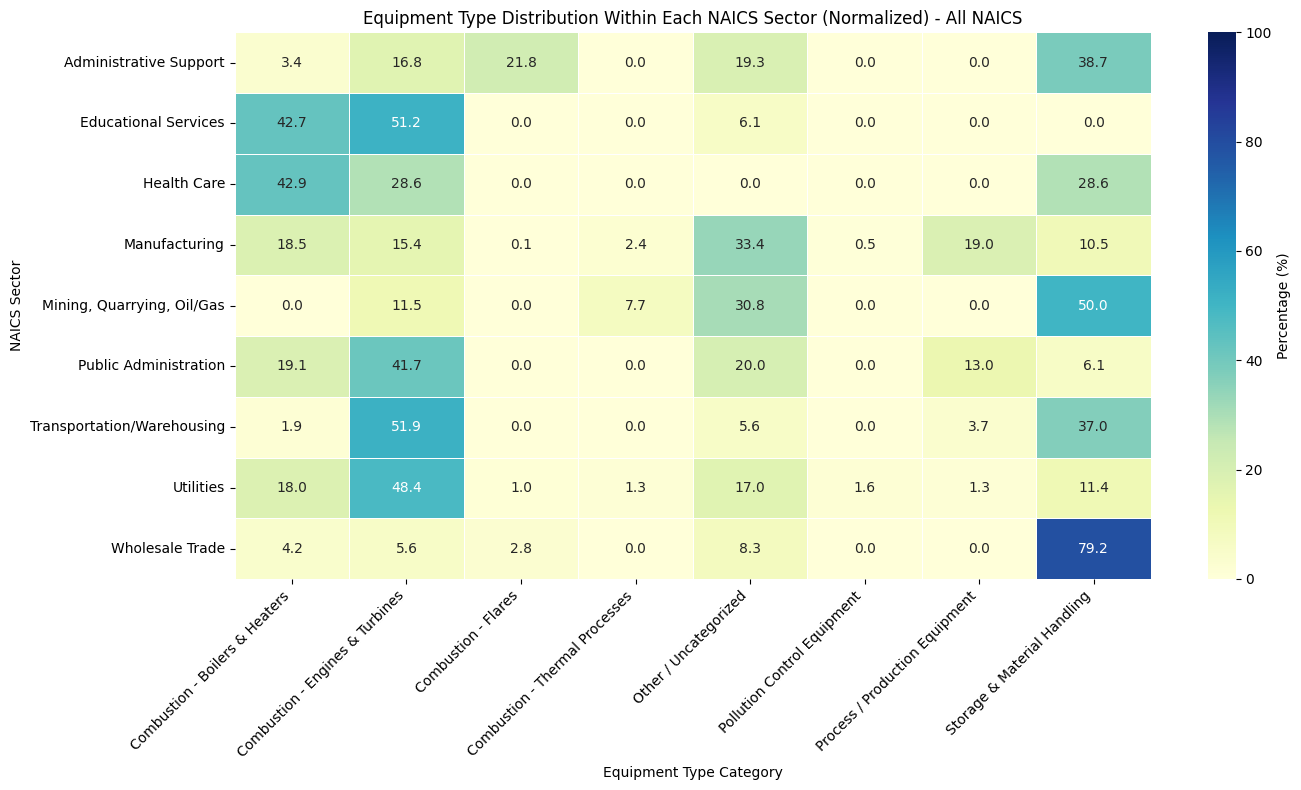

In [35]:
# Normalized view: proportion of equipment types within each NAICS sector (All NAICS)
naics_equip_matrix_norm_all = naics_equip_matrix_all.div(naics_equip_matrix_all.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(
    naics_equip_matrix_norm_all,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Percentage (%)"},
    linewidths=0.5,
    vmin=0,
    vmax=100,
)
plt.title("Equipment Type Distribution Within Each NAICS Sector (Normalized) - All NAICS")
plt.xlabel("Equipment Type Category")
plt.ylabel("NAICS Sector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [36]:
total_units = len(df_industry)
unique_facilities = df_industry["Facility Name"].nunique()

print(f"Total emission units (Industry NAICS Only): {total_units:,}")
print(f"Unique facilities: {unique_facilities:,}")

availability_cols = [col for col in field_availability_columns if col in df_industry.columns]
availability_df = df_industry[availability_cols]

availability_summary = (1 - availability_df.isna().mean()).sort_values(ascending=False)
availability_summary = (availability_summary * 100).round(1)
availability_summary


Total emission units (Industry NAICS Only): 1,398
Unique facilities: 107


Unit ID                100.0
Unit Description        99.8
Unit Type               99.7
Unit Type Category      99.7
Capacity Unit           85.1
Unit Quantity           71.4
Capacity Value          66.8
Fuel Type Category      53.2
Fuel Type               53.2
Unit Make               51.3
Unit Model              41.1
Year of Manufacture     31.2
Equipment Age           31.2
Annual Run Hours         4.9
Rated Efficiency         0.0
dtype: float64

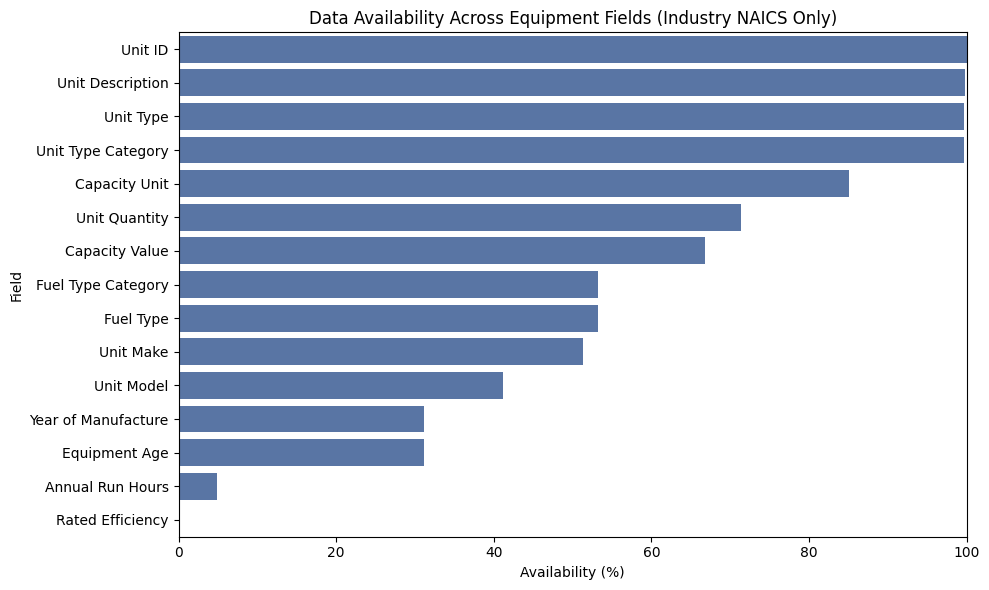

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x=availability_summary.values, y=availability_summary.index, color="#4c72b0")
plt.xlabel("Availability (%)")
plt.ylabel("Field")
plt.title("Data Availability Across Equipment Fields (Industry NAICS Only)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


## Equipment Types and Quantities


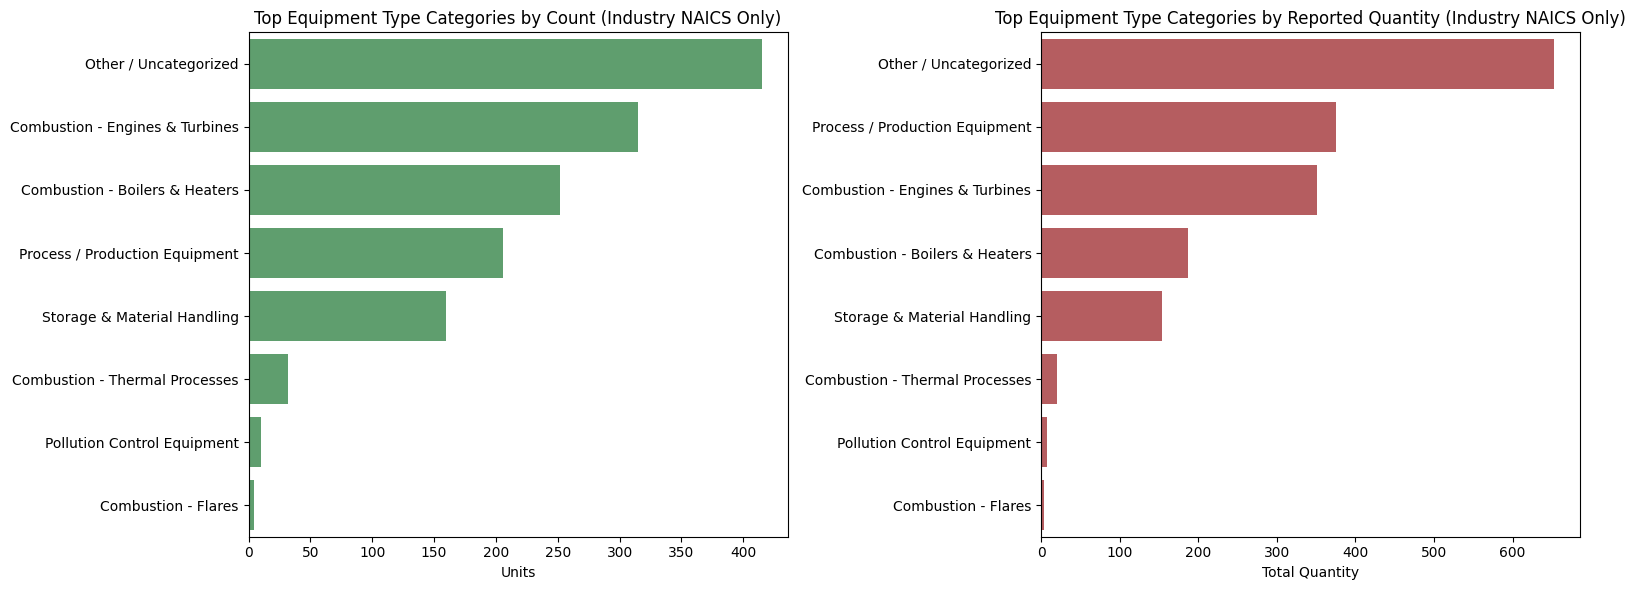

Unit Type Category
Other / Uncategorized              415
Combustion - Engines & Turbines    315
Combustion - Boilers & Heaters     252
Process / Production Equipment     206
Storage & Material Handling        160
Combustion - Thermal Processes      32
Pollution Control Equipment         10
Combustion - Flares                  4
Name: count, dtype: int64

In [38]:
type_counts = df_industry["Unit Type Category"].dropna().value_counts().head(20)
type_quantity = (
    df_industry.dropna(subset=["Unit Type Category", "Unit Quantity"])
      .groupby("Unit Type Category")["Unit Quantity"].sum()
      .sort_values(ascending=False)
      .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=type_counts.values, y=type_counts.index, ax=axes[0], color="#55a868")
axes[0].set_title("Top Equipment Type Categories by Count (Industry NAICS Only)")
axes[0].set_xlabel("Units")
axes[0].set_ylabel("")

sns.barplot(x=type_quantity.values, y=type_quantity.index, ax=axes[1], color="#c44e52")
axes[1].set_title("Top Equipment Type Categories by Reported Quantity (Industry NAICS Only)")
axes[1].set_xlabel("Total Quantity")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

type_counts.head(10)


## Equipment Age Distribution


count    436.000000
mean      29.314220
std       16.562799
min        1.000000
25%       16.000000
50%       28.000000
75%       40.000000
90%       55.000000
max       78.000000
Name: Equipment Age, dtype: float64


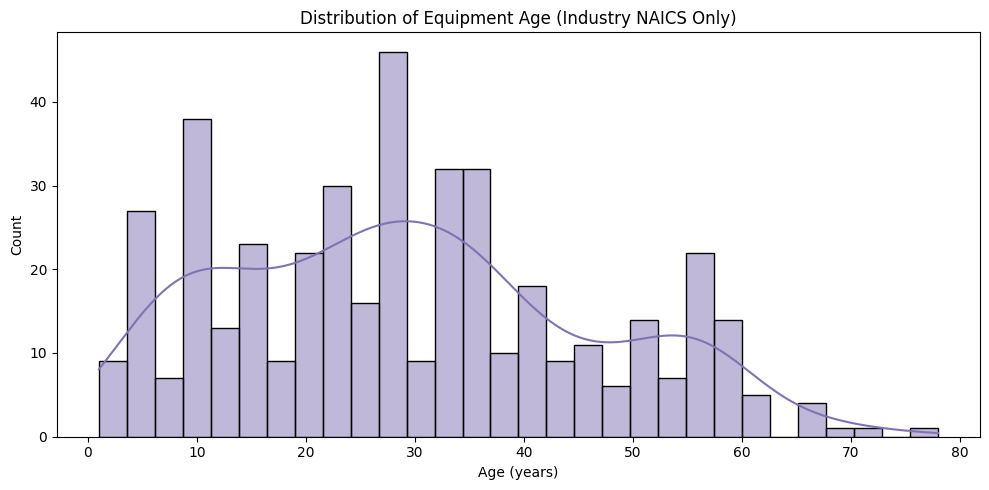

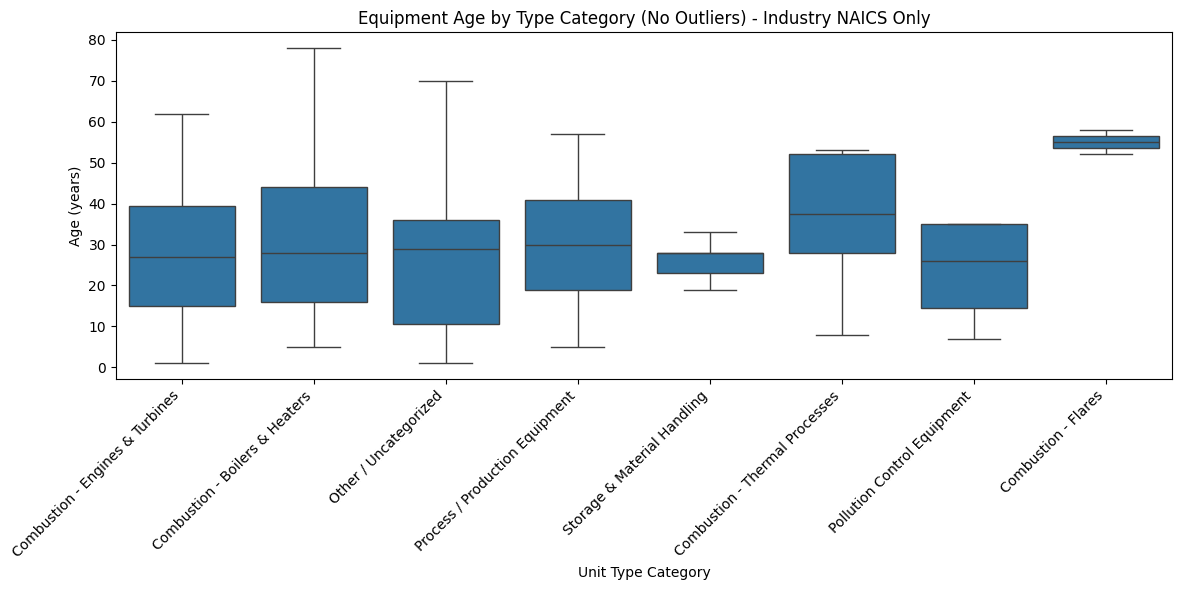

In [39]:
age_data = df_industry["Equipment Age"].dropna()

age_summary = age_data.describe(percentiles=[0.25, 0.5, 0.75, 0.9])
print(age_summary)

plt.figure(figsize=(10, 5))
sns.histplot(age_data, bins=30, kde=True, color="#8172b2")
plt.title("Distribution of Equipment Age (Industry NAICS Only)")
plt.xlabel("Age (years)")
plt.tight_layout()
plt.show()

age_by_category = df_industry.dropna(subset=["Unit Type Category", "Equipment Age"])

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=age_by_category,
    x="Unit Type Category",
    y="Equipment Age",
    showfliers=False,
)
plt.xticks(rotation=45, ha="right")
plt.title("Equipment Age by Type Category (No Outliers) - Industry NAICS Only")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()


## Equipment Capacity and Size


In [40]:
capacity_df = df_industry.dropna(subset=["Capacity Value", "Capacity Unit"])

capacity_by_unit = (
    capacity_df.groupby("Capacity Unit")
    .agg(count=("Capacity Value", "size"),
         median_capacity=("Capacity Value", "median"),
         p90_capacity=("Capacity Value", lambda x: np.nanpercentile(x, 90)))
    .sort_values("count", ascending=False)
)

capacity_by_unit.head(10)


,count,median_capacity,p90_capacity
Capacity Unit,,,
MMBtu/hr,295,12.50,2.557500e+02
gallons,72,300.00,2.315000e+04
HP,52,197.90,5.804000e+02
tons/hr,47,80.00,2.690000e+02
lbs/hr,36,300.00,1.500000e+03
hp,32,277.50,1.201380e+03
MMBTU/hr,21,8.03,2.650000e+01
BTU/hr,21,33500000.00,1.150000e+08
lb/hr output,19,64.00,2.500000e+02


## Capacity by Equipment Type


In [41]:
# Filter to equipment with both capacity and fuel type (fuel-using equipment)
capacity_fuel_df = df_industry.dropna(subset=["Capacity Value", "Fuel Type Category", "Unit Type Category"])

# Get top equipment types by count for better visualization
top_equip_for_capacity = capacity_fuel_df["Unit Type Category"].value_counts().head(8).index
capacity_fuel_filtered = capacity_fuel_df[capacity_fuel_df["Unit Type Category"].isin(top_equip_for_capacity)]

print(f"Equipment with capacity and fuel type data: {len(capacity_fuel_filtered):,}")
print(f"\nEquipment types included:")
for eq_type in top_equip_for_capacity:
    count = len(capacity_fuel_filtered[capacity_fuel_filtered["Unit Type Category"] == eq_type])
    print(f"  {eq_type}: {count} units")


Equipment with capacity and fuel type data: 569

Equipment types included:
  Combustion - Engines & Turbines: 260 units
  Combustion - Boilers & Heaters: 198 units
  Other / Uncategorized: 56 units
  Process / Production Equipment: 24 units
  Storage & Material Handling: 16 units
  Combustion - Thermal Processes: 14 units
  Combustion - Flares: 1 units


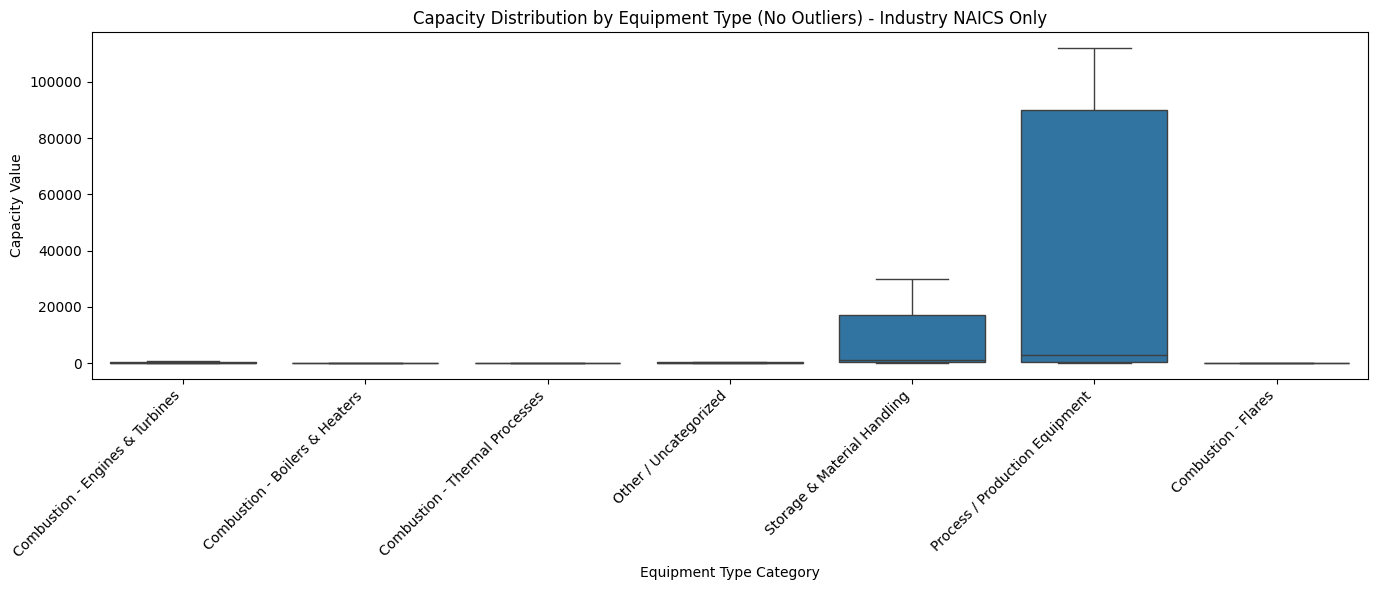


Capacity Summary Statistics by Equipment Type:
                                 count   median         mean          std  \
Unit Type Category                                                          
Combustion - Engines & Turbines    260    74.10    172464.48   1738542.54   
Combustion - Boilers & Heaters     198    28.90   1697154.97   8444496.84   
Other / Uncategorized               56     7.38  10180635.84  30491885.86   
Process / Production Equipment      24  3000.00  20035265.55  97972089.56   
Storage & Material Handling         16  1000.00      7803.26     11425.55   
Combustion - Thermal Processes      14    32.50        52.23        72.82   
Combustion - Flares                  1    30.00        30.00          NaN   

                                   min          max  
Unit Type Category                                   
Combustion - Engines & Turbines   0.05   20900000.0  
Combustion - Boilers & Heaters    0.32   65350000.0  
Other / Uncategorized             0.16  11

In [42]:
# Box plot of capacity by equipment type
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=capacity_fuel_filtered,
    x="Unit Type Category",
    y="Capacity Value",
    showfliers=False,
)
plt.xticks(rotation=45, ha="right")
plt.title("Capacity Distribution by Equipment Type (No Outliers) - Industry NAICS Only")
plt.ylabel("Capacity Value")
plt.xlabel("Equipment Type Category")
plt.tight_layout()
plt.show()

# Summary statistics
capacity_summary = (
    capacity_fuel_filtered.groupby("Unit Type Category")["Capacity Value"]
    .agg(["count", "median", "mean", "std", "min", "max"])
    .round(2)
    .sort_values("count", ascending=False)
)
print("\nCapacity Summary Statistics by Equipment Type:")
print(capacity_summary)


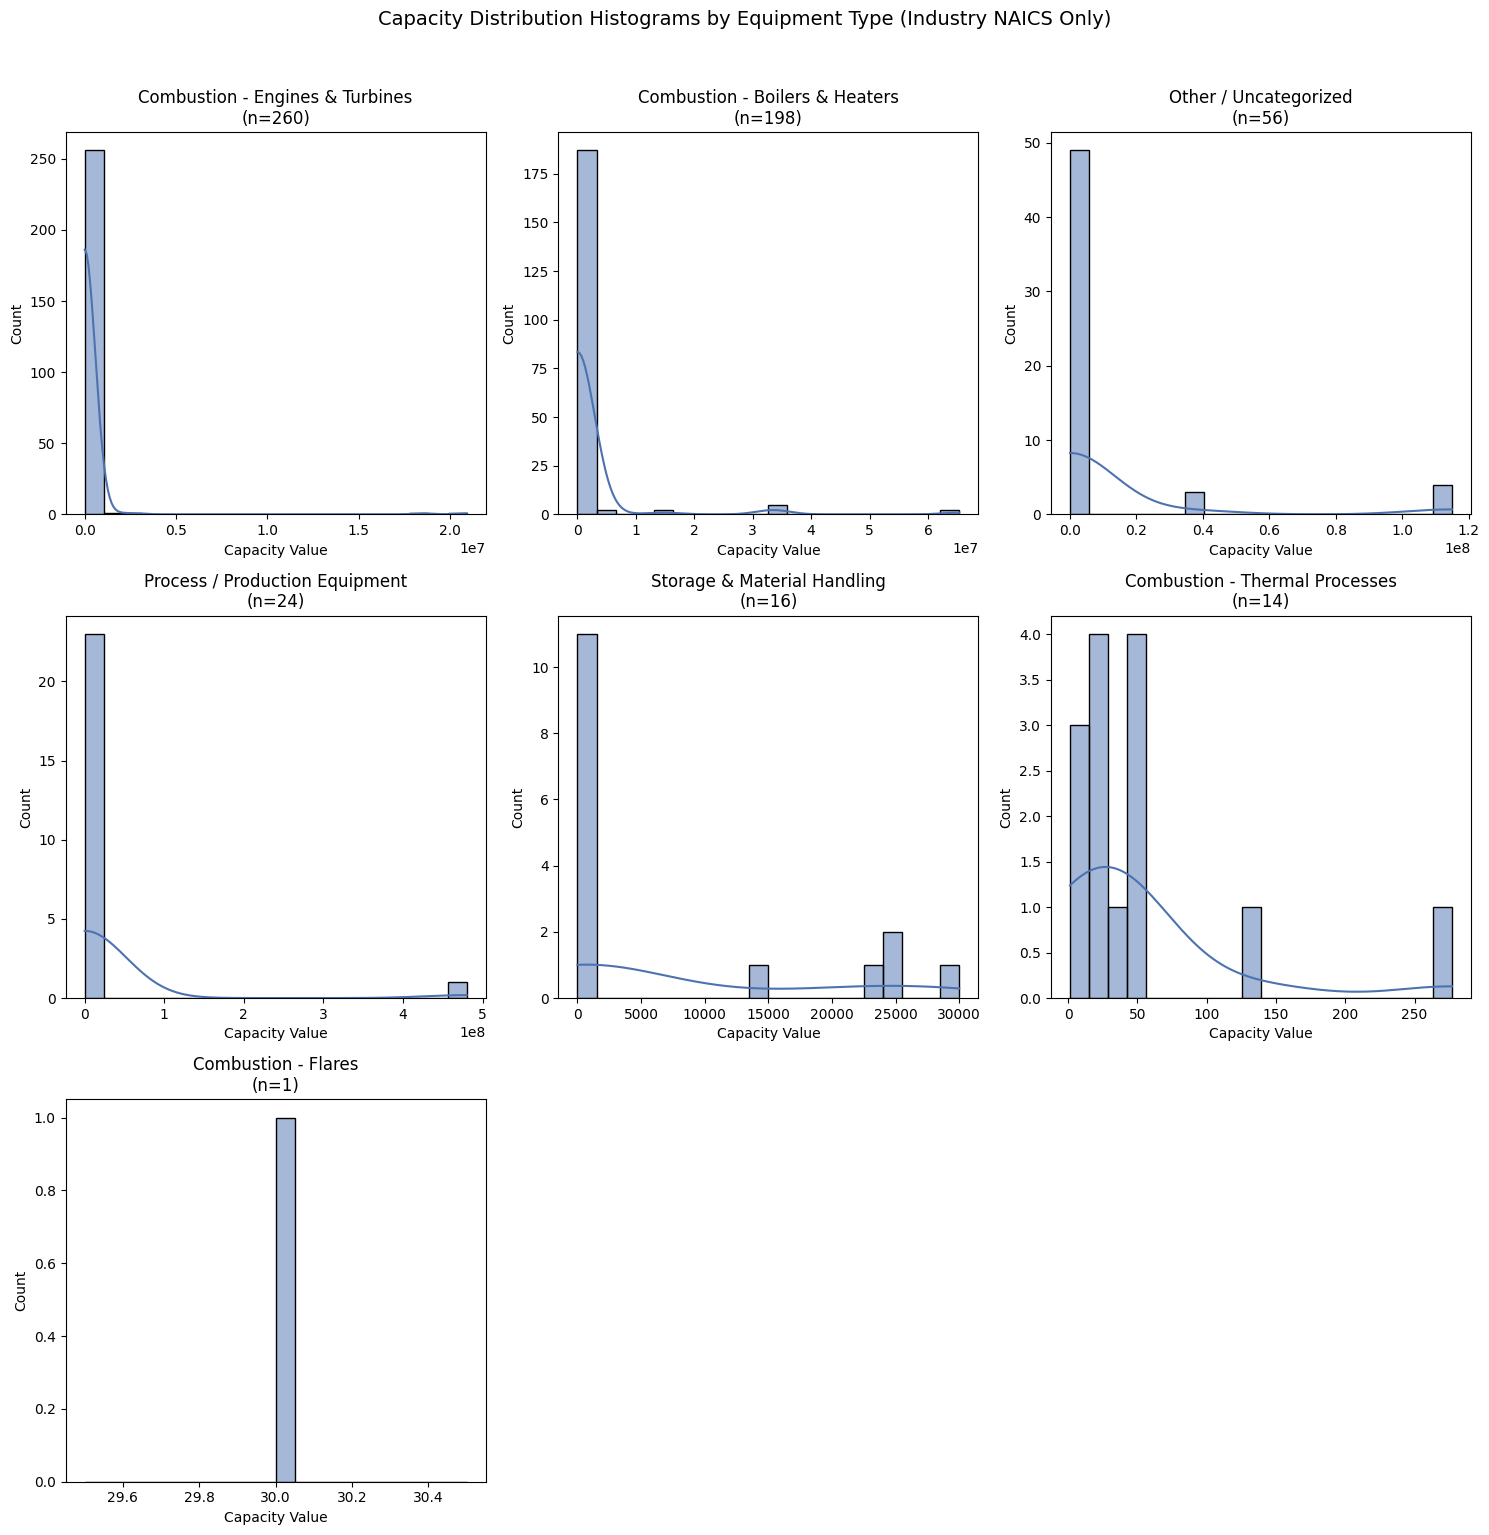

In [43]:
# Histograms by equipment type - faceted view
n_types = len(top_equip_for_capacity)
n_cols = 3
n_rows = (n_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_types > 1 else [axes]

for idx, eq_type in enumerate(top_equip_for_capacity):
    subset = capacity_fuel_filtered[capacity_fuel_filtered["Unit Type Category"] == eq_type]
    if len(subset) > 0:
        sns.histplot(
            data=subset,
            x="Capacity Value",
            bins=20,
            kde=True,
            ax=axes[idx],
            color="#4c72b0",
        )
        axes[idx].set_title(f"{eq_type}\n(n={len(subset)})")
        axes[idx].set_xlabel("Capacity Value")
        axes[idx].set_ylabel("Count")

# Hide unused subplots
for idx in range(n_types, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Capacity Distribution Histograms by Equipment Type (Industry NAICS Only)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [44]:
# Focus on most common capacity unit for better comparison
capacity_unit_counts = capacity_fuel_df["Capacity Unit"].value_counts()
print("Top capacity units:")
print(capacity_unit_counts.head(10))

# Filter to most common unit (likely MMBtu/hr for fuel-using equipment)
most_common_unit = capacity_unit_counts.index[0]
capacity_single_unit = capacity_fuel_df[capacity_fuel_df["Capacity Unit"] == most_common_unit]

top_equip_single_unit = capacity_single_unit["Unit Type Category"].value_counts().head(8).index
capacity_single_unit_filtered = capacity_single_unit[
    capacity_single_unit["Unit Type Category"].isin(top_equip_single_unit)
]

print(f"\nEquipment with {most_common_unit}: {len(capacity_single_unit_filtered):,} units")


Top capacity units:
Capacity Unit
MMBtu/hr          294
HP                 49
hp                 32
BTU/hr             21
MMBTU/hr           21
kW                 18
gallons            14
MMBtu per hour      9
ft²/hr              8
BHP                 8
Name: count, dtype: int64

Equipment with MMBtu/hr: 294 units


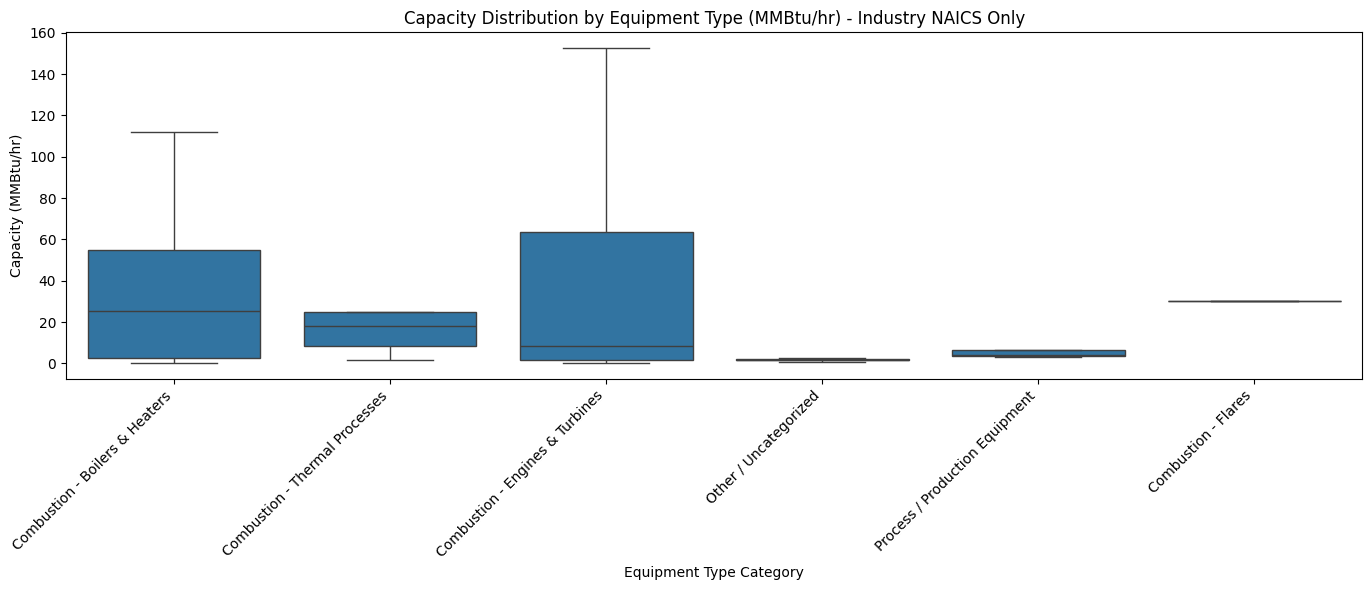

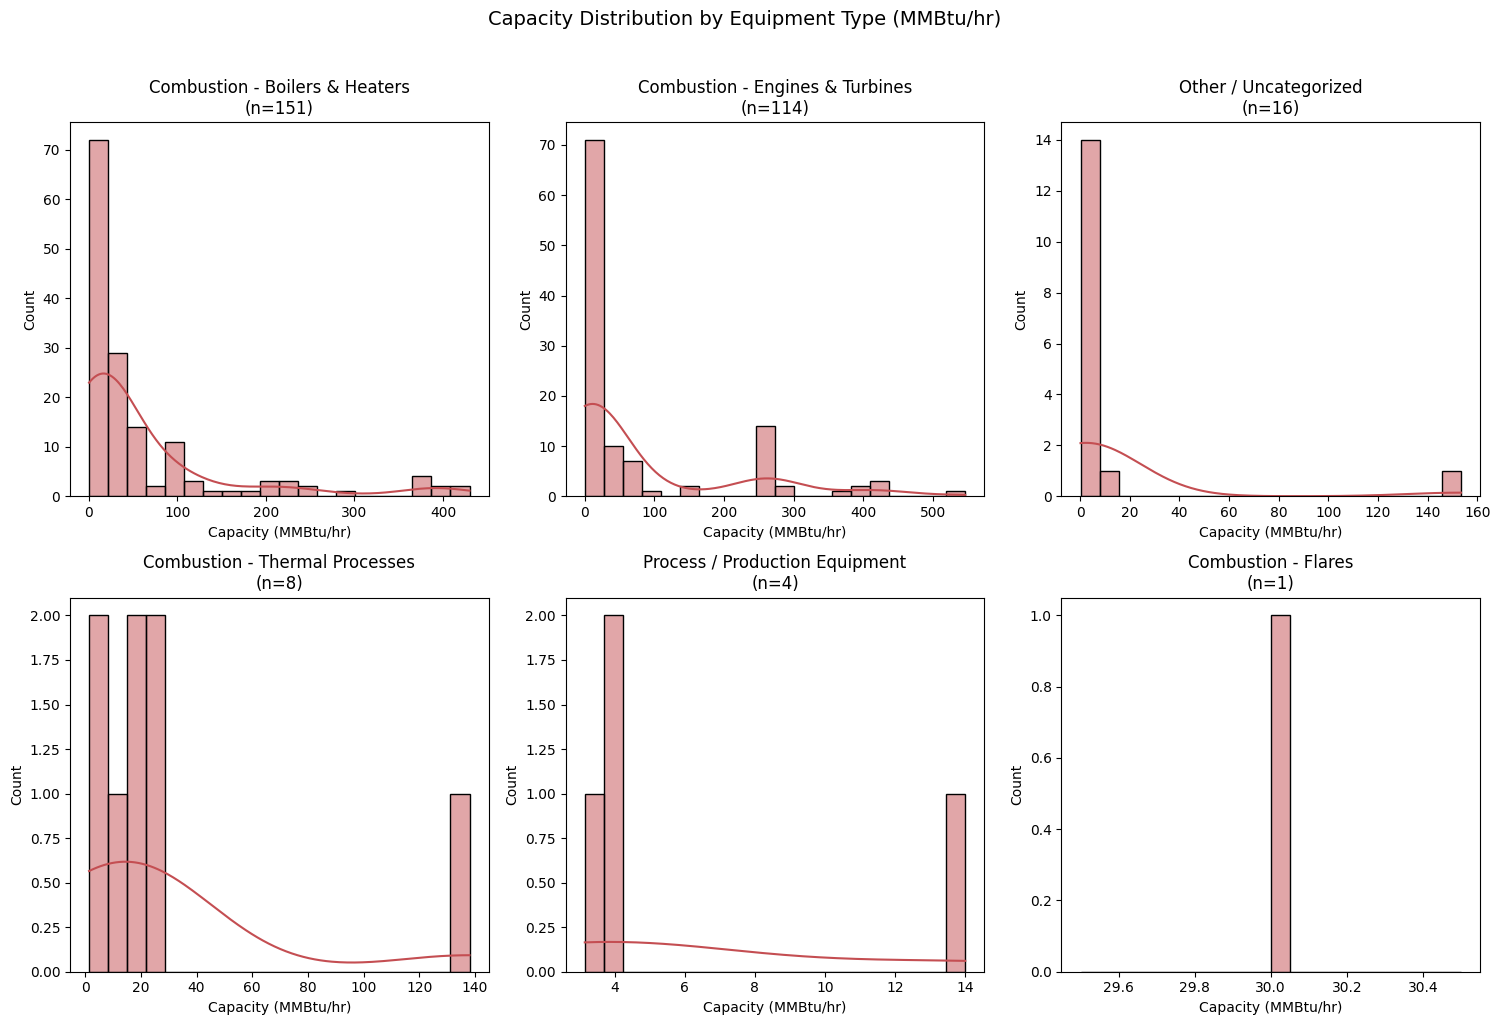

In [45]:
# Box plot for most common capacity unit
if len(capacity_single_unit_filtered) > 0:
    plt.figure(figsize=(14, 6))
    sns.boxplot(
        data=capacity_single_unit_filtered,
        x="Unit Type Category",
        y="Capacity Value",
        showfliers=False,
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Capacity Distribution by Equipment Type ({most_common_unit}) - Industry NAICS Only")
    plt.ylabel(f"Capacity ({most_common_unit})")
    plt.xlabel("Equipment Type Category")
    plt.tight_layout()
    plt.show()
    
    # Histograms for most common unit
    n_types = len(top_equip_single_unit)
    n_cols = 3
    n_rows = (n_types + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_types > 1 else [axes]
    
    for idx, eq_type in enumerate(top_equip_single_unit):
        subset = capacity_single_unit_filtered[
            capacity_single_unit_filtered["Unit Type Category"] == eq_type
        ]
        if len(subset) > 0:
            sns.histplot(
                data=subset,
                x="Capacity Value",
                bins=20,
                kde=True,
                ax=axes[idx],
                color="#c44e52",
            )
            axes[idx].set_title(f"{eq_type}\n(n={len(subset)})")
            axes[idx].set_xlabel(f"Capacity ({most_common_unit})")
            axes[idx].set_ylabel("Count")
    
    # Hide unused subplots
    for idx in range(n_types, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(
        f"Capacity Distribution by Equipment Type ({most_common_unit})",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


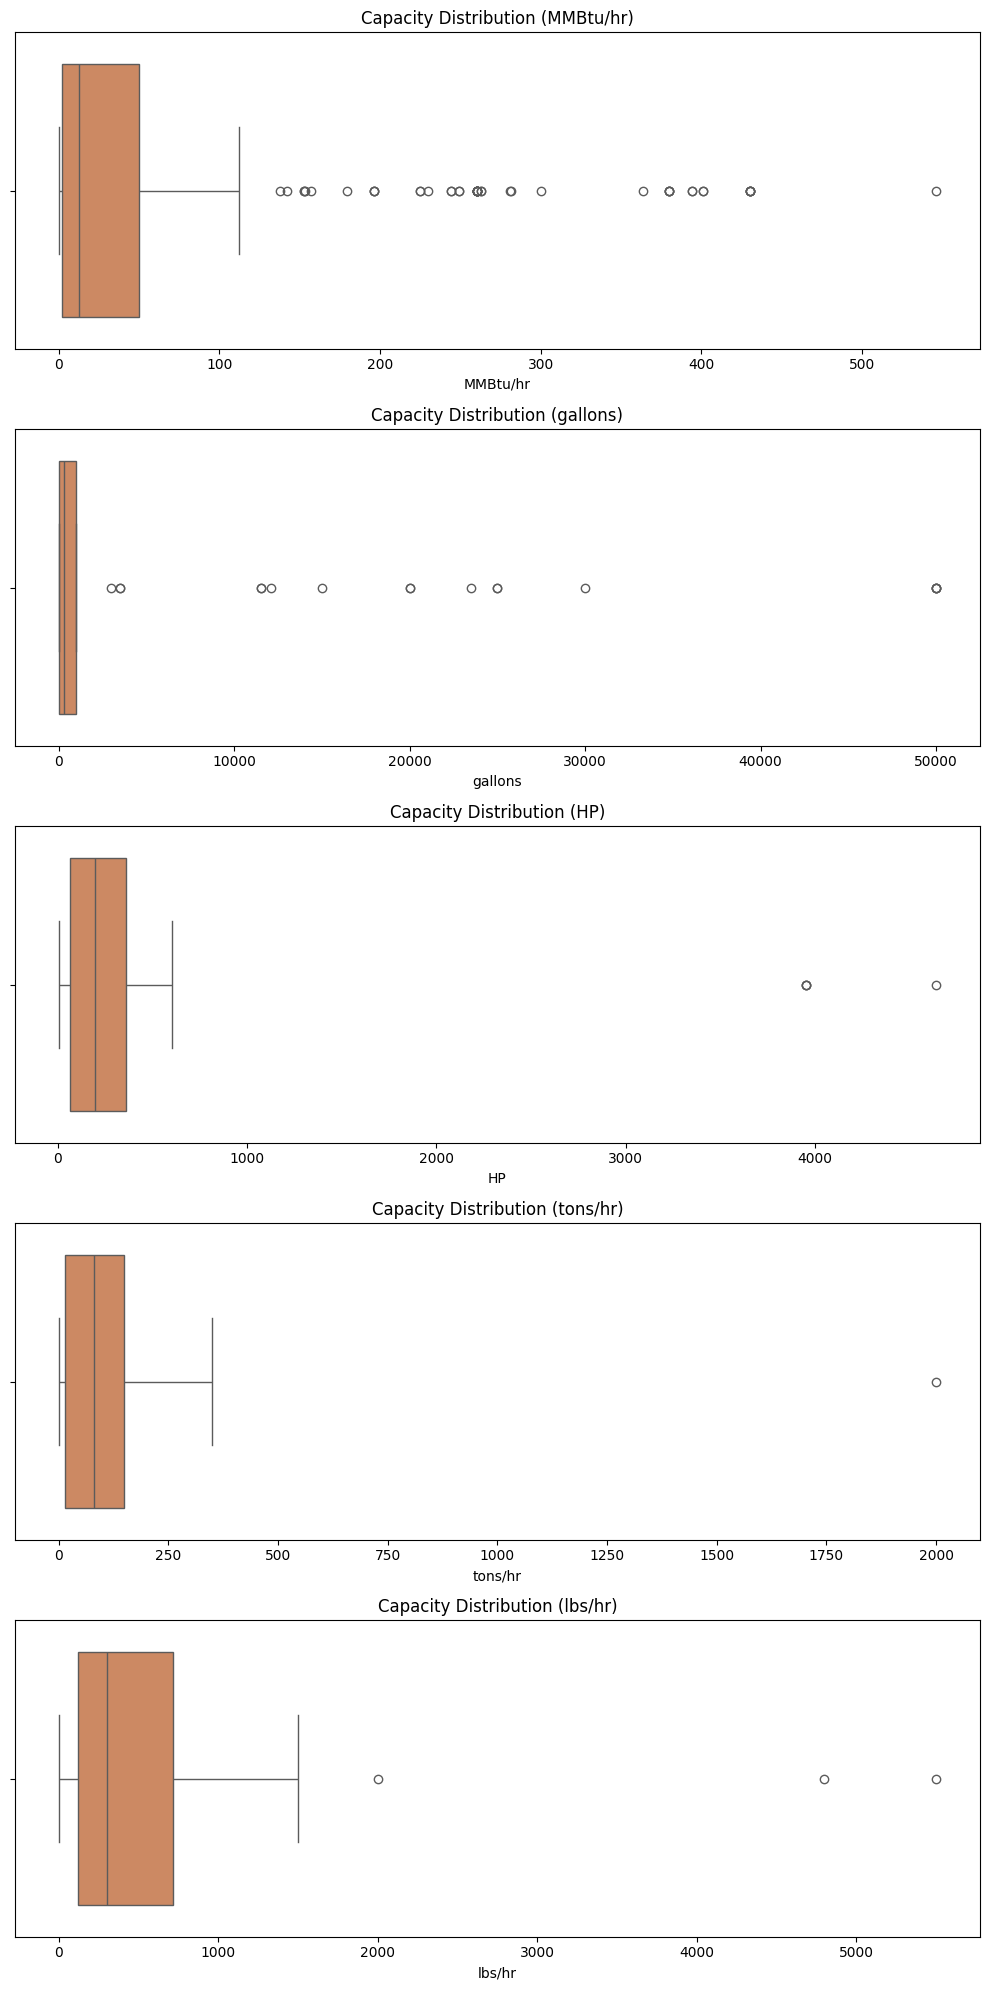

In [46]:
top_capacity_units = capacity_by_unit.head(5).index

fig, axes = plt.subplots(len(top_capacity_units), 1, figsize=(10, 4 * len(top_capacity_units)))

if len(top_capacity_units) == 1:
    axes = [axes]

for ax, unit in zip(axes, top_capacity_units):
    subset = capacity_df[capacity_df["Capacity Unit"] == unit]
    sns.boxplot(x=subset["Capacity Value"], ax=ax, color="#dd8452")
    ax.set_title(f"Capacity Distribution ({unit})")
    ax.set_xlabel(unit)

plt.tight_layout()
plt.show()


## Fuel Type Mix


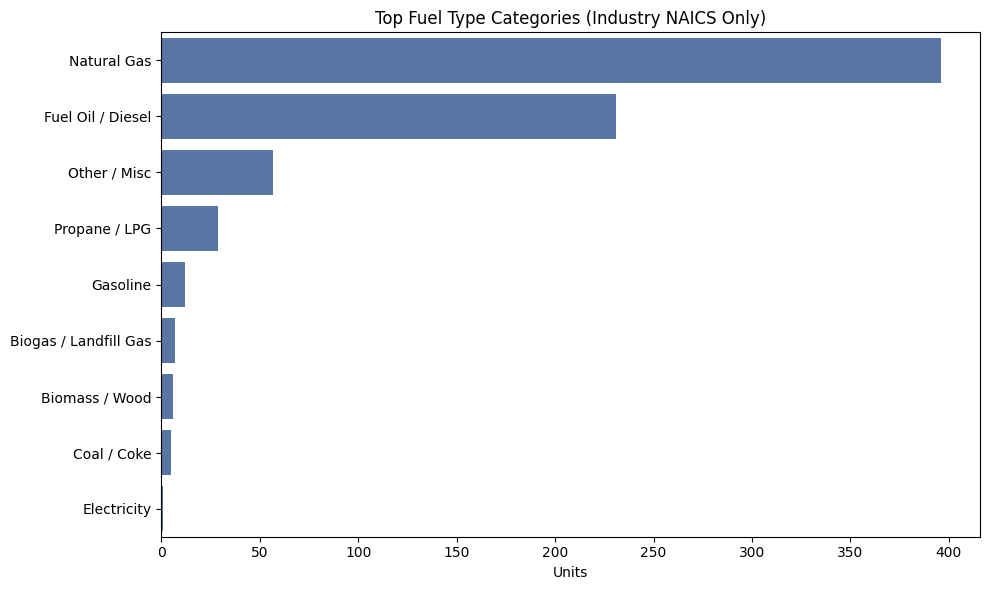

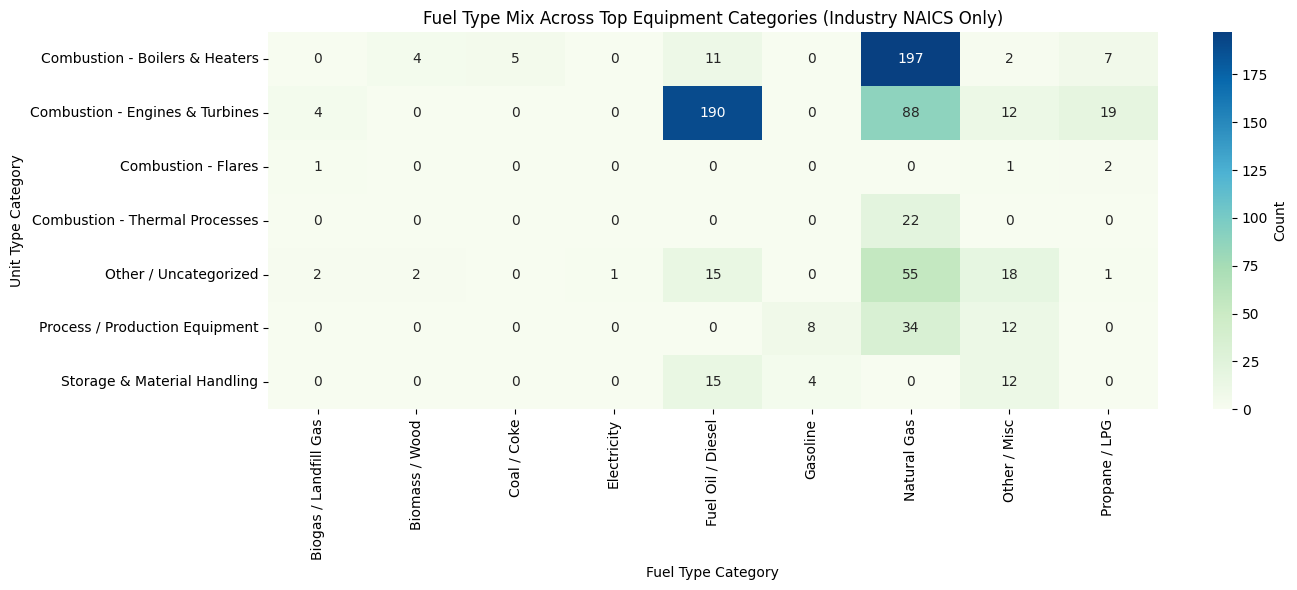

In [47]:
fuel_counts = df_industry["Fuel Type Category"].dropna().value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=fuel_counts.values, y=fuel_counts.index, color="#4c72b0")
plt.title("Top Fuel Type Categories (Industry NAICS Only)")
plt.xlabel("Units")
plt.ylabel("")
plt.tight_layout()
plt.show()

fuel_type_by_unit = (
    df_industry.dropna(subset=["Fuel Type Category", "Unit Type Category"])
      .groupby(["Unit Type Category", "Fuel Type Category"])
      .size()
      .reset_index(name="count")
)

top_unit_types = type_counts.index[:10]
top_fuel_types = fuel_counts.index[:10]

fuel_pivot = (
    fuel_type_by_unit[
        fuel_type_by_unit["Unit Type Category"].isin(top_unit_types)
        & fuel_type_by_unit["Fuel Type Category"].isin(top_fuel_types)
    ]
        .pivot_table(
            index="Unit Type Category",
            columns="Fuel Type Category",
            values="count",
            fill_value=0,
        )
)

plt.figure(figsize=(14, 6))
sns.heatmap(fuel_pivot, annot=True, fmt="g", cmap="GnBu", cbar_kws={"label": "Count"})
plt.title("Fuel Type Mix Across Top Equipment Categories (Industry NAICS Only)")
plt.xlabel("Fuel Type Category")
plt.ylabel("Unit Type Category")
plt.tight_layout()
plt.show()


## Manufacturer Representation


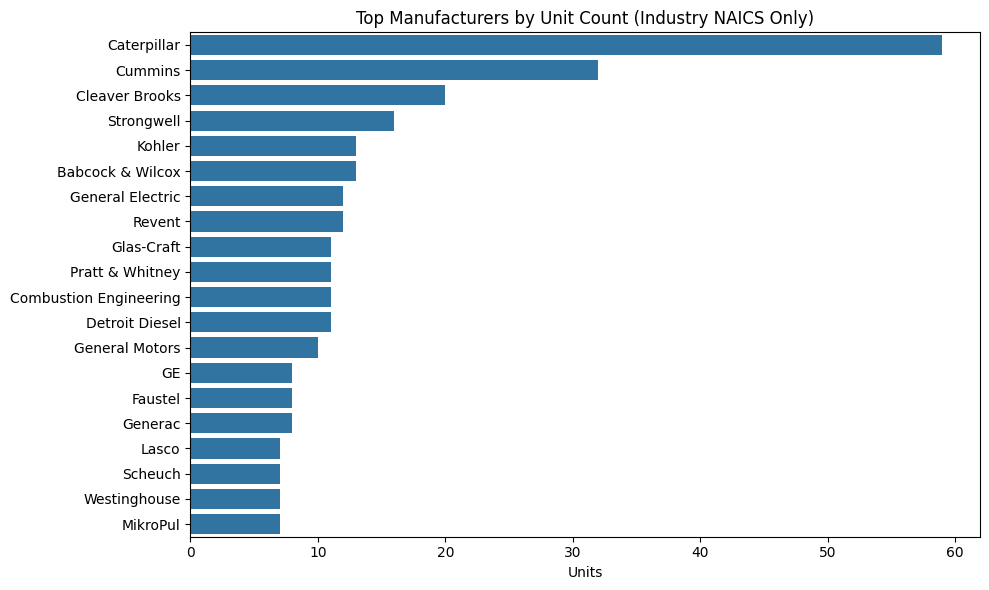

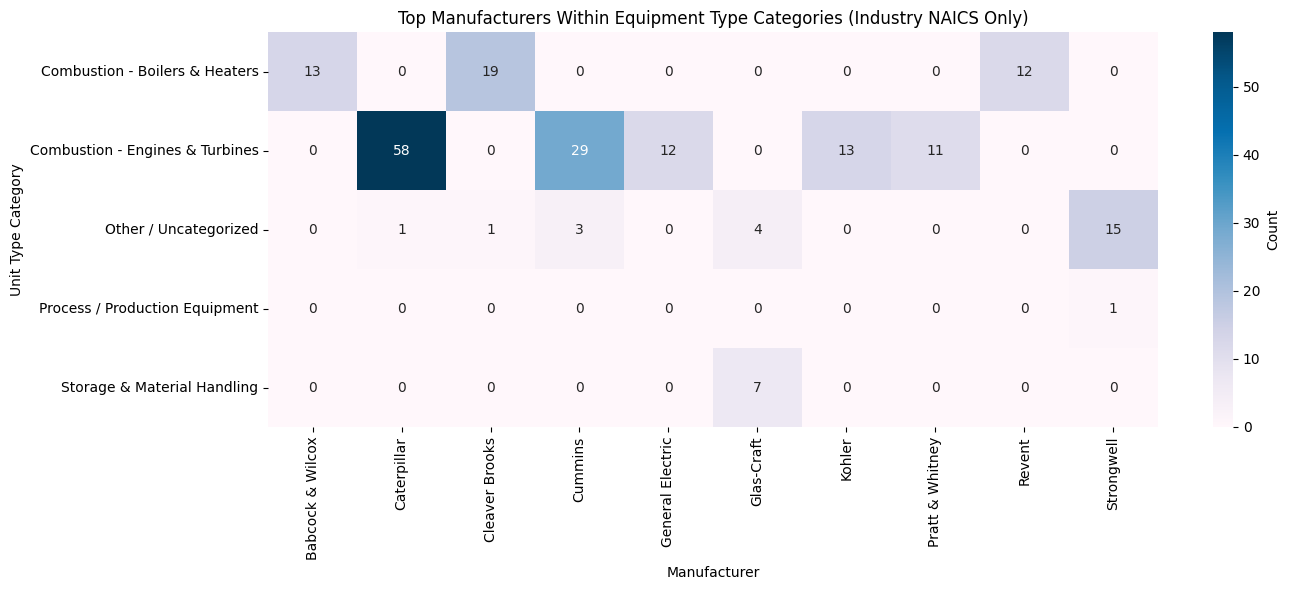

In [48]:
manufacturer_counts = df_industry["Unit Make"].dropna().value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=manufacturer_counts.values, y=manufacturer_counts.index, color="#1f77b4")
plt.title("Top Manufacturers by Unit Count (Industry NAICS Only)")
plt.xlabel("Units")
plt.ylabel("")
plt.tight_layout()
plt.show()

manufacturers_by_type = (
    df_industry.dropna(subset=["Unit Make", "Unit Type Category"])
      .groupby(["Unit Type Category", "Unit Make"])
      .size()
      .reset_index(name="count")
)

top_manufacturers = manufacturer_counts.index[:10]
top_types = type_counts.index[:10]

manufacturer_matrix = (
    manufacturers_by_type[
        manufacturers_by_type["Unit Make"].isin(top_manufacturers)
        & manufacturers_by_type["Unit Type Category"].isin(top_types)
    ]
    .pivot_table(index="Unit Type Category", columns="Unit Make", values="count", fill_value=0)
)

plt.figure(figsize=(14, 6))
sns.heatmap(manufacturer_matrix, cmap="PuBu", annot=True, fmt="g", cbar_kws={"label": "Count"})
plt.title("Top Manufacturers Within Equipment Type Categories (Industry NAICS Only)")
plt.xlabel("Manufacturer")
plt.ylabel("Unit Type Category")
plt.tight_layout()
plt.show()


## NAICS Code and Equipment Type Analysis


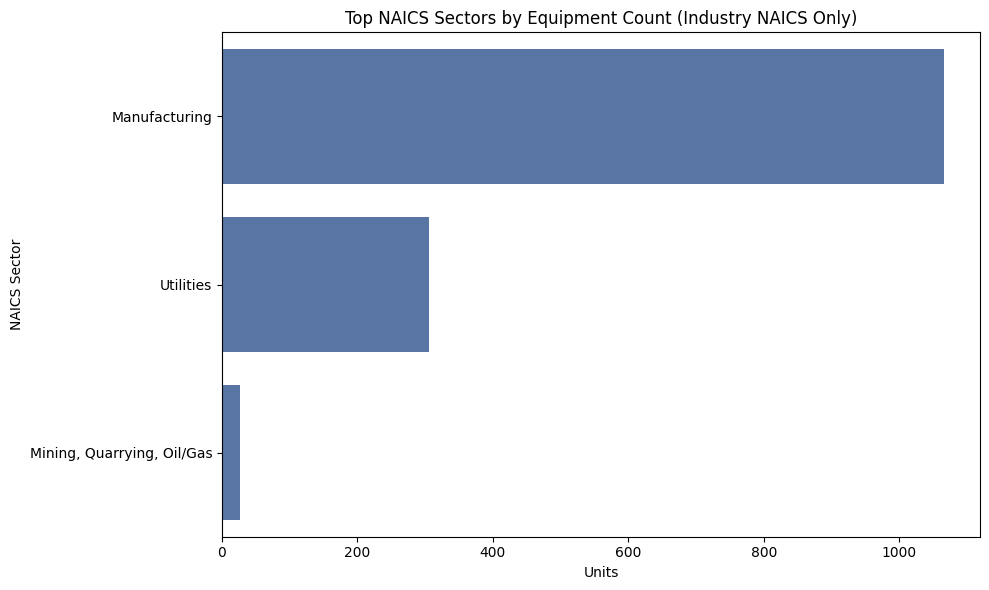

NAICS Sector Name
Manufacturing                 1066
Utilities                      306
Mining, Quarrying, Oil/Gas      26
Name: count, dtype: int64

In [49]:
# Clean and categorize NAICS codes (for industry-filtered data)
df_industry["NAICS Code"] = df_industry["NAICS Code"].astype(str).str.strip()
df_industry.loc[df_industry["NAICS Code"].isin(["nan", "", "None"]), "NAICS Code"] = np.nan

# Extract 2-digit NAICS sector code
df_industry["NAICS Sector"] = df_industry["NAICS Code"].str[:2]
df_industry.loc[df_industry["NAICS Sector"].str.len() < 2, "NAICS Sector"] = np.nan

# Map 2-digit codes to sector names
naics_sector_map = {
    "11": "Agriculture, Forestry, Fishing",
    "21": "Mining, Quarrying, Oil/Gas",
    "22": "Utilities",
    "23": "Construction",
    "31": "Manufacturing",
    "32": "Manufacturing",
    "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade",
    "45": "Retail Trade",
    "48": "Transportation/Warehousing",
    "49": "Transportation/Warehousing",
    "51": "Information",
    "52": "Finance/Insurance",
    "53": "Real Estate",
    "54": "Professional Services",
    "55": "Management",
    "56": "Administrative Support",
    "61": "Educational Services",
    "62": "Health Care",
    "71": "Arts/Entertainment",
    "72": "Accommodation/Food",
    "81": "Other Services",
    "92": "Public Administration",
}

df_industry["NAICS Sector Name"] = df_industry["NAICS Sector"].map(naics_sector_map)

naics_counts = df_industry["NAICS Sector Name"].dropna().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=naics_counts.values, y=naics_counts.index, color="#4c72b0")
plt.title("Top NAICS Sectors by Equipment Count (Industry NAICS Only)")
plt.xlabel("Units")
plt.ylabel("NAICS Sector")
plt.tight_layout()
plt.show()

naics_counts.head(10)


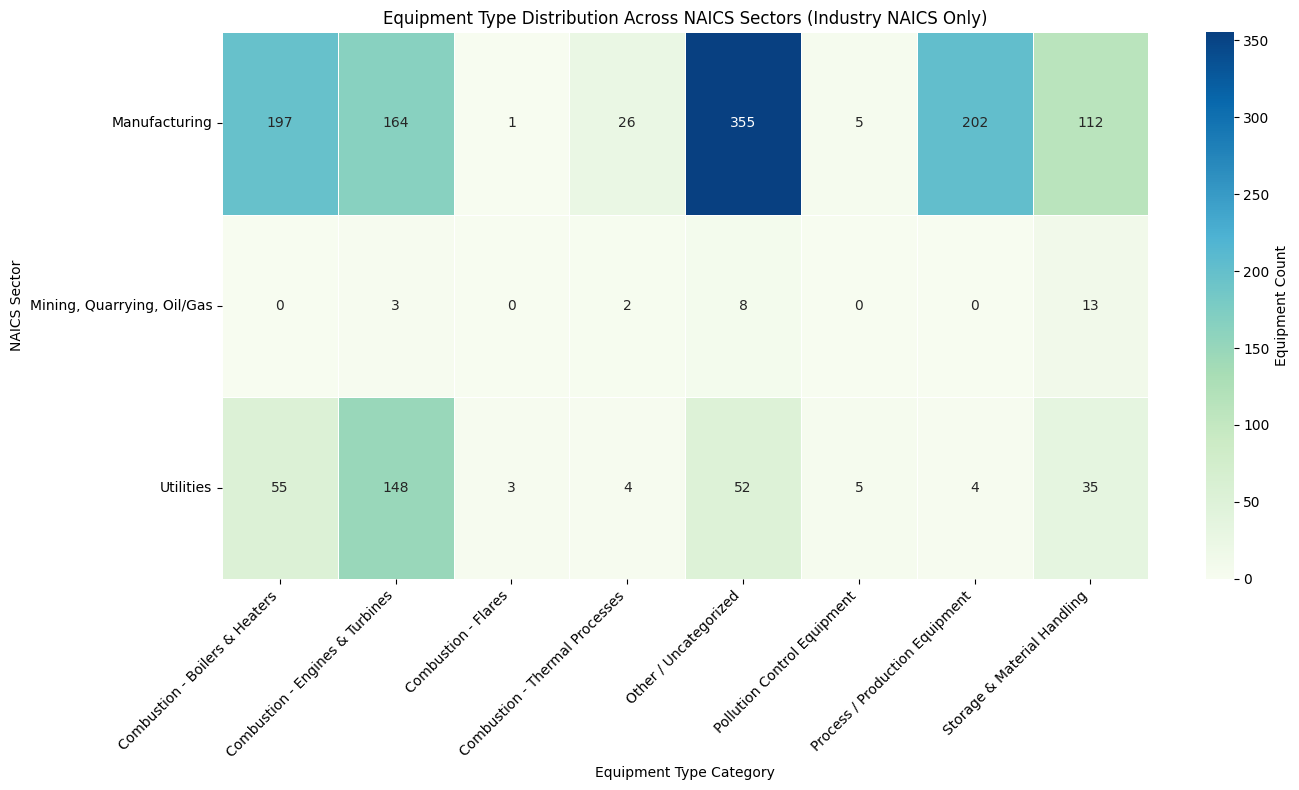

In [50]:
# Cross-tabulation of NAICS sectors and equipment types
naics_equipment = (
    df_industry.dropna(subset=["NAICS Sector Name", "Unit Type Category"])
      .groupby(["NAICS Sector Name", "Unit Type Category"])
      .size()
      .reset_index(name="count")
)

top_naics = naics_counts.index[:10]
top_equip_types = type_counts.index[:10]

naics_equip_matrix = (
    naics_equipment[
        naics_equipment["NAICS Sector Name"].isin(top_naics)
        & naics_equipment["Unit Type Category"].isin(top_equip_types)
    ]
    .pivot_table(
        index="NAICS Sector Name",
        columns="Unit Type Category",
        values="count",
        fill_value=0,
    )
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    naics_equip_matrix,
    annot=True,
    fmt="g",
    cmap="GnBu",
    cbar_kws={"label": "Equipment Count"},
    linewidths=0.5,
)
plt.title("Equipment Type Distribution Across NAICS Sectors (Industry NAICS Only)")
plt.xlabel("Equipment Type Category")
plt.ylabel("NAICS Sector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


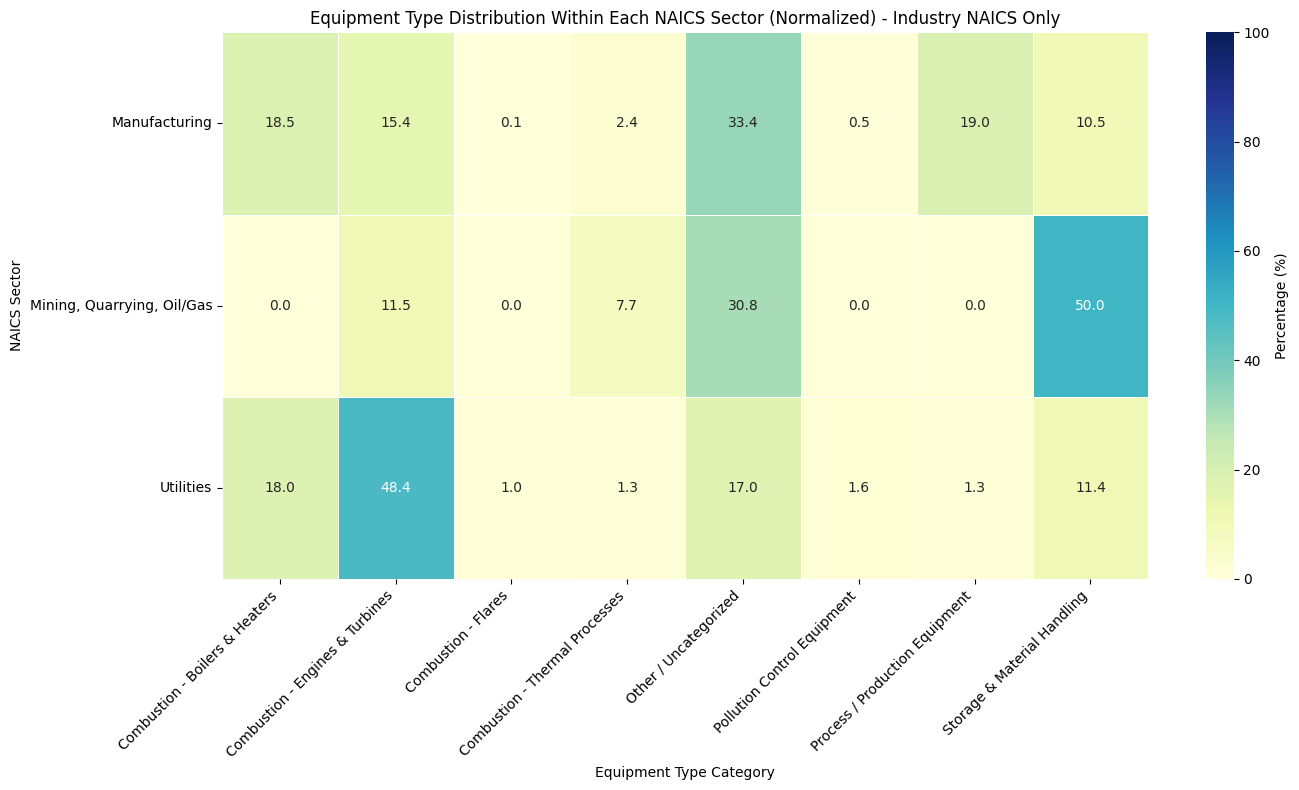

In [51]:
# Normalized view: proportion of equipment types within each NAICS sector
naics_equip_matrix_norm = naics_equip_matrix.div(naics_equip_matrix.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(
    naics_equip_matrix_norm,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Percentage (%)"},
    linewidths=0.5,
    vmin=0,
    vmax=100,
)
plt.title("Equipment Type Distribution Within Each NAICS Sector (Normalized) - Industry NAICS Only")
plt.xlabel("Equipment Type Category")
plt.ylabel("NAICS Sector")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Notes and Next Steps

- Consider normalizing capacity values to common units for comparable sizing insights.
- Investigate unit descriptions with missing types to improve classification.
- Review manufacturers with low counts but high capacities for potential niche opportunities.
